Python is a **high-level, interpreted programming language** known for its **simplicity, readability, and versatility**. It is widely used in web development, data science, automation, artificial intelligence (AI), machine learning (ML), and more.

---

### 🔹 Key Features of Python:

* **Simple syntax**: Easy to read and write, like plain English.
* **Interpreted**: No need to compile; runs line-by-line using an interpreter.
* **Dynamically typed**: No need to declare variable types explicitly.
* **Cross-platform**: Runs on Windows, macOS, Linux, etc.
* **Large standard library**: Comes with built-in modules for file handling, math, web services, etc.
* **Huge ecosystem**: Thousands of third-party libraries (e.g., NumPy, Pandas, Flask, Django, TensorFlow).

---

### 🔹 Example Code:

```python
# Hello World in Python
print("Hello, World!")
```

---

### 🔹 What Can You Do With Python?

| Area                   | Libraries/Frameworks      |
| ---------------------- | ------------------------- |
| Web Development        | Flask, Django             |
| Data Science           | Pandas, NumPy, Matplotlib |
| Machine Learning       | scikit-learn, TensorFlow  |
| Automation/Scripting   | os, shutil, Selenium      |
| Game Development       | Pygame                    |
| APIs and Microservices | FastAPI, Flask            |


In [1]:
a = 100
b = 200
c = a + b

In [2]:
print(a)


100


In [3]:
print(b)

200


In [4]:
a = 100
b = float(a)
print(b)
print(type(b))

100.0
<class 'float'>


In [7]:
a = 100.0
b = 200.2
c = a + b
print(c)
print(type(c))

300.2
<class 'float'>


In [2]:
a = input("Enter : ")
print(a)

1000


In [23]:
"""
pip install requests beautifulsoup4 pandas
Run: python scrape_quotes.py
"""
from __future__ import annotations
import time
from typing import List, Dict, Optional
import requests
from bs4 import BeautifulSoup
import pandas as pd

BASE_URL = "https://quotes.toscrape.com"
HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; BS4-Tutorial/1.0; +https://example.com/bot)"
}
TIMEOUT = 15
RETRY = 3
SLEEP_BETWEEN_REQUESTS = 0.6  # be nice

def get(url: str) -> Optional[requests.Response]:
    """GET with basic retries/backoff."""
    for attempt in range(1, RETRY + 1):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
            if resp.status_code == 200:
                return resp
            # handle transient 5xx
            if 500 <= resp.status_code < 600:
                time.sleep(0.8 * attempt)
            else:
                print(f"[{resp.status_code}] {url}")
                return None
        except requests.RequestException as e:
            if attempt == RETRY:
                print(f"Request failed ({url}): {e}")
            time.sleep(0.8 * attempt)
    return None

def parse_quotes(page_html: str) -> List[Dict]:
    """Extract quote, author, tags from a page."""
    soup = BeautifulSoup(page_html, "html.parser")

    data = []
    for q in soup.select("div.quote"):
        text = q.select_one("span.text")
        author = q.select_one("small.author")
        tags = [t.get_text(strip=True) for t in q.select("div.tags a.tag")]
        data.append({
            "quote": (text.get_text(strip=True) if text else ""),
            "author": (author.get_text(strip=True) if author else ""),
            "tags": ", ".join(tags)
        })
    # find next page href
    next_link = soup.select_one("li.next a")
    next_url = BASE_URL + next_link.get("href") if next_link else None
    return data, next_url

def crawl_all() -> pd.DataFrame:
    url = BASE_URL
    all_rows: List[Dict] = []

    seen = set()
    while url and url not in seen:
        seen.add(url)
        print(f"Crawling: {url}")
        resp = get(url)
        if not resp:
            break
        rows, next_url = parse_quotes(resp.text)
        all_rows.extend(rows)
        url = next_url
        time.sleep(SLEEP_BETWEEN_REQUESTS)

    return pd.DataFrame(all_rows)

def main():
    df = crawl_all()
    if df.empty:
        print("No data scraped.")
        return

    # quick checks / examples
    print(df.head(3).to_string(index=False))
    print(f"\nTotal quotes: {len(df)} | Unique authors: {df['author'].nunique()}")

    out_csv = "quotes.csv"
    df.to_csv(out_csv, index=False, encoding="utf-8")
    print(f"Saved -> {out_csv}")

if __name__ == "__main__":
    main()


Crawling: https://quotes.toscrape.com
Crawling: https://quotes.toscrape.com/page/2/
Crawling: https://quotes.toscrape.com/page/3/
Crawling: https://quotes.toscrape.com/page/4/
Crawling: https://quotes.toscrape.com/page/5/
Crawling: https://quotes.toscrape.com/page/6/
Crawling: https://quotes.toscrape.com/page/7/
Crawling: https://quotes.toscrape.com/page/8/
Crawling: https://quotes.toscrape.com/page/9/
Crawling: https://quotes.toscrape.com/page/10/
                                                                                                                              quote          author                                         tags
                “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.” Albert Einstein       change, deep-thoughts, thinking, world
                                              “It is our choices, Harry, that show what we truly are, far more than our abilities.”    J.K. Rowling              

In [1]:
!pip install requests
!pip install lxml
!pip install bs4

  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
Using cached urllib3-2.5.0-py3-none-any.whl (129 kB)

   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------- ----------------------------- 1/4 [charset_normalizer]
   ---------- ----------------------------- 1/4 [charset_normalizer]
   -------------------- ------------------- 2/4 [certifi]
   ------------------------------ --------- 3/4 [requests]
   ---------------------------------------- 4/4 [requests]




[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------------- -------------------------- 1.3/4.0 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 17.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached soupsieve-2.7-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.14.1-py3-none-any.whl.metadata (3.0 kB)
Using cached soupsieve-2.7-py3-none-any.whl (36 kB)
Using cached typing_extensions-4.14.1-py3-none-any.whl (43 kB)

   ---------- ----------------------------- 1/4 [soupsieve]
   -------------------- ------------------- 2/4 [beautifulsoup4]
   -------------------- ------------------- 2/4 [beautifulsoup4]
   ---------------------------------------- 4/4 [bs4]




[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
df = pd.read_csv("quotes.csv")
print(df)

                                                quote              author  \
0   “The world as we have created it is a process ...     Albert Einstein   
1   “It is our choices, Harry, that show what we t...        J.K. Rowling   
2   “There are only two ways to live your life. On...     Albert Einstein   
3   “The person, be it gentleman or lady, who has ...         Jane Austen   
4   “Imperfection is beauty, madness is genius and...      Marilyn Monroe   
..                                                ...                 ...   
95  “You never really understand a person until yo...          Harper Lee   
96  “You have to write the book that wants to be w...   Madeleine L'Engle   
97  “Never tell the truth to people who are not wo...          Mark Twain   
98        “A person's a person, no matter how small.”           Dr. Seuss   
99  “... a mind needs books as a sword needs a whe...  George R.R. Martin   

                                                 tags  
0              chan

In [1]:
import requests

In [3]:
res = requests.get("http://www.example.com")

In [4]:
type(res)

requests.models.Response

In [5]:
res.text

'<!doctype html>\n<html>\n<head>\n    <title>Example Domain</title>\n\n    <meta charset="utf-8" />\n    <meta http-equiv="Content-type" content="text/html; charset=utf-8" />\n    <meta name="viewport" content="width=device-width, initial-scale=1" />\n    <style type="text/css">\n    body {\n        background-color: #f0f0f2;\n        margin: 0;\n        padding: 0;\n        font-family: -apple-system, system-ui, BlinkMacSystemFont, "Segoe UI", "Open Sans", "Helvetica Neue", Helvetica, Arial, sans-serif;\n        \n    }\n    div {\n        width: 600px;\n        margin: 5em auto;\n        padding: 2em;\n        background-color: #fdfdff;\n        border-radius: 0.5em;\n        box-shadow: 2px 3px 7px 2px rgba(0,0,0,0.02);\n    }\n    a:link, a:visited {\n        color: #38488f;\n        text-decoration: none;\n    }\n    @media (max-width: 700px) {\n        div {\n            margin: 0 auto;\n            width: auto;\n        }\n    }\n    </style>    \n</head>\n\n<body>\n<div>\n    <

In [2]:
import bs4

In [7]:
soup = bs4.BeautifulSoup(res.text,"lxml")

In [8]:
soup

<!DOCTYPE html>
<html>
<head>
<title>Example Domain</title>
<meta charset="utf-8"/>
<meta content="text/html; charset=utf-8" http-equiv="Content-type"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<style type="text/css">
    body {
        background-color: #f0f0f2;
        margin: 0;
        padding: 0;
        font-family: -apple-system, system-ui, BlinkMacSystemFont, "Segoe UI", "Open Sans", "Helvetica Neue", Helvetica, Arial, sans-serif;
        
    }
    div {
        width: 600px;
        margin: 5em auto;
        padding: 2em;
        background-color: #fdfdff;
        border-radius: 0.5em;
        box-shadow: 2px 3px 7px 2px rgba(0,0,0,0.02);
    }
    a:link, a:visited {
        color: #38488f;
        text-decoration: none;
    }
    @media (max-width: 700px) {
        div {
            margin: 0 auto;
            width: auto;
        }
    }
    </style>
</head>
<body>
<div>
<h1>Example Domain</h1>
<p>This domain is for use in illustrative examples

In [16]:
len(soup.select('p'))

2

In [12]:
title_tag = soup.select('title')

In [17]:
soup.select(".vector-toc-text")

[]

In [18]:
data = soup.select('p')

In [19]:
data[0].getText()

'This domain is for use in illustrative examples in documents. You may use this\n    domain in literature without prior coordination or asking for permission.'

In [20]:
data[1].getText()

'More information...'

In [22]:
!pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   ----------- ---------------------------- 3.1/11.0 MB 10.8 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.0 MB 13.3 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.0 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 13.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ----------- ---------------------------- 3.7/12.8 MB 18.2 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.8 MB 17.7 MB/s eta 0:00:01
   ----------------------------- ---------- 9.4/12.8 MB 15.9 MB/s eta 0:00:01
   -------------------------------------- - 12.3/12.8 MB 15.4 MB/s eta 0:00:01
   ----------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# First get the request
# res = requests.get('https://en.wikipedia.org/wiki/Grace_Hopper')
res = requests.get('https://webscraper.io/test-sites/e-commerce/allinone')

In [24]:
# Create a soup from request
soup = bs4.BeautifulSoup(res.text,"lxml")

In [25]:
data = []
for tag in soup.find_all(['h1', 'h2', 'h3', 'p','div']):
    data.append({
        'tag': tag.name,
        'text': tag.getText(strip=True),
        'Attribute' : tag.attrs
    })

In [26]:
import json
with open('data.json', 'w') as f:
    json.dump(data, f)

In [27]:
print(data)

[{'tag': 'div', 'text': 'Toggle navigationWeb ScraperCloud ScraperPricingLearnDocumentationVideo TutorialsTest SitesForumInstallCloud Login', 'Attribute': {'class': ['container']}}, {'tag': 'div', 'text': 'Toggle navigation', 'Attribute': {'class': ['navbar-header']}}, {'tag': 'div', 'text': '', 'Attribute': {'class': ['navbar-brand']}}, {'tag': 'div', 'text': 'Web ScraperCloud ScraperPricingLearnDocumentationVideo TutorialsTest SitesForumInstallCloud Login', 'Attribute': {'class': ['side-collapse', 'in']}}, {'tag': 'p', 'text': 'Web Scraper', 'Attribute': {}}, {'tag': 'div', 'text': '', 'Attribute': {'class': ['crta']}}, {'tag': 'p', 'text': 'Cloud Scraper', 'Attribute': {}}, {'tag': 'div', 'text': '', 'Attribute': {'class': ['crta']}}, {'tag': 'p', 'text': 'Pricing', 'Attribute': {}}, {'tag': 'div', 'text': '', 'Attribute': {'class': ['crta']}}, {'tag': 'p', 'text': 'Learn', 'Attribute': {}}, {'tag': 'div', 'text': 'Test SitesHomeComputersPhonesE-commerce training siteWelcome to WebS

In [31]:
import pandas as pd
df = pd.DataFrame(data)
df

,tag,text,Attribute
0,h2,Contents,{'class': ['vector-pinnable-header-label']}
1,h1,Grace Hopper,"{'id': 'firstHeading', 'class': ['firstHeading..."
2,p,,{'class': ['mw-empty-elt']}
3,p,"Grace Brewster Hopper(néeMurray; December 9, 1...",{}
4,p,"Before joining the Navy, Hopper earned a Ph.D....",{}
5,p,She believed that programming should be simpli...,{}
6,p,The U.S. NavyArleigh Burke-classguided-missile...,{}
7,h2,Early life and education,{'id': 'Early_life_and_education'}
8,p,Grace Brewster Murray was born inNew York City...,{}
9,p,Grace was very curious as a child; this was a ...,{}


In [33]:
df.to_csv('wiki.csv')

In [34]:
import re


In [ ]:
text = "The person's phone number is 408-555-1234. Call soon!"
pattern = 'phone'

In [36]:
'phone' in text

True

In [37]:
re.search('phone',text)

<re.Match object; span=(13, 18), match='phone'>

In [28]:
# Set user-agent to mimic a browser
# --- IGNORE ---
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
res = requests.get('https://en.wikipedia.org/wiki/Grace_Hopper', headers=headers)

In [29]:
res.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Grace Hopper - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-

In [30]:
soup = bs4.BeautifulSoup(res.text,"lxml")

In [31]:
data = []
for tag in soup.find_all(['h1', 'h2', 'h3', 'p','div']):
    data.append({
        'tag': tag.name,
        'text': tag.getText(strip=True),
        'Attribute' : tag.attrs
    })

In [32]:
data

[{'tag': 'div',
  'text': 'Main menuMain menumove to sidebarhideNavigationMain pageContentsCurrent eventsRandom articleAbout WikipediaContact usContributeHelpLearn to editCommunity portalRecent changesUpload fileSpecial pagesSearchSearchAppearanceDonateCreate accountLog inPersonal toolsDonateCreate accountLog inPages for logged out editorslearn moreContributionsTalk',
  'Attribute': {'class': ['vector-header-container']}},
 {'tag': 'div',
  'text': 'Main menuMain menumove to sidebarhideNavigationMain pageContentsCurrent eventsRandom articleAbout WikipediaContact usContributeHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages',
  'Attribute': {'class': ['vector-header-start']}},
 {'tag': 'div',
  'text': 'Main menuMain menumove to sidebarhideNavigationMain pageContentsCurrent eventsRandom articleAbout WikipediaContact usContributeHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages',
  'Attribute': {'id': 'vector-main-menu-dropdown',
   'class': ['

In [7]:
import numpy as np

a = np.array([1,2,3,4,5])
a[1:4]

array([2, 3, 4])

array([['1', '2'],
       ['3', '4']], dtype='<U21')

In [9]:
data = np.loadtxt('wiki.csv', delimiter=',', dtype=str, skiprows=1, usecols=(0,1,2))

In [10]:
data

array([['0', 'h2', 'Contents'],
       ['1', 'h1', 'Grace Hopper'],
       ['2', 'p', ''],
       ['3', 'p', '"Grace Brewster Hopper(nÃ©eMurray; December 9'],
       ['4', 'p', '"Before joining the Navy'],
       ['5', 'p',
        '"She believed that programming should be simplified with an English-based computer programming language. Her compiler converted English terms intomachine codeunderstood by computers. By 1952'],
       ['6', 'p',
        '"The U.S. NavyArleigh Burke-classguided-missile destroyerUSSHopperwas named for her'],
       ['7', 'h2', 'Early life and education'],
       ['8', 'p',
        '"Grace Brewster Murray was born inNew York City. She was the eldest of three children. Her parents'],
       ['9', 'p',
        '"Grace was very curious as a child; this was a lifelong trait. At the age of seven'],
       ['10', 'p', '"In 1930'],
       ['11', 'p', '"In 1934'],
       ['12', 'h2', 'Career'],
       ['13', 'h3', 'World War II'],
       ['14', 'p',
        '"Hopper t

In [17]:
data.shape

(60, 3)

In [19]:
data.size

180

In [ ]:
np.random.randint(0,8,size=3)

array([6, 2, 6], dtype=int32)

In [35]:
# numpy matrix multplication
a = np.array([[1,2,3],[4,5,6]])
b = np.array([[7,8],[9,10],[11,12]])
a @ b

array([[ 58,  64],
       [139, 154]])

In [36]:
np.dot(a,b)

array([[ 58,  64],
       [139, 154]])

In [37]:
# Generate 5 numbers between 1 and 10
arr = np.linspace(1, 10, num=5)
print(arr)

[ 1.    3.25  5.5   7.75 10.  ]


In [38]:
arr, step = np.linspace(0, 1, num=5, retstep=True)
print("Array:", arr)
print("Step size:", step)

Array: [0.   0.25 0.5  0.75 1.  ]
Step size: 0.25


In [ ]:
# Importing a custom package
import sample_package as mn
v = mn.NameOfClass()
v.display_info()

'Name: John, Age: 32'

In [1]:
# Importing a custom package module
from sample_package import NameOfClass
v = NameOfClass()
v.display_info()
v.sample_function(10, 20)

30

In [16]:
class NameData:
    name = ''
    age = '100'
    def __init__(self, name = 'Vineet Tiwari', age = '32'):
        self.name = name
        self.age = age

    def display_info(self):
        return f"Name: {self.name}, Age: {self.age}"
    
    @staticmethod
    def sample_function(param1, param2):
        return param1 + param2
    
    @classmethod
    def get_age(cls):
        return cls.age

In [17]:
obj = NameData() 
print(obj.display_info()) 
print(obj.sample_function(10, 20))
print("#######",obj.get_age())

Name: Vineet Tiwari, Age: 32
30
####### 100


# **Module vs Package in Python**

### **1. Module**

* A **module** is simply a **single Python file** (`.py`) containing functions, classes, or variables.
* You import it directly.

✅ Example: `mymodule.py`

```python
# mymodule.py
def greet(name):
    return f"Hello, {name}"
```

Use it:

```python
import mymodule
print(mymodule.greet("Vineet"))  # Hello, Vineet
```

---

### **2. Package**

* A **package** is a **collection of modules (folder with multiple `.py` files)**.
* It must contain an `__init__.py` file (can be empty) so Python recognizes it as a package.

✅ Example folder structure:

```
mypackage/
    __init__.py
    greetings.py
    maths.py
```

`greetings.py`

```python
def say_hello(name):
    return f"Hi, {name}"
```

`maths.py`

```python
def add(a, b):
    return a + b
```

Use the package:

```python
from mypackage import greetings, maths

print(greetings.say_hello("Vineet"))  # Hi, Vineet
print(maths.add(2, 3))                # 5
```

---

### **Key Differences**

| Feature      | Module                    | Package                                                 |
| ------------ | ------------------------- | ------------------------------------------------------- |
| Definition   | Single `.py` file         | Folder with multiple modules + `__init__.py`            |
| Import Style | `import mymodule`         | `from mypackage import module`                          |
| Organization | Small programs            | Large projects                                          |
| Example      | `math` (Python’s math.py) | `numpy`, `pandas` (they are packages with many modules) |

---

👉 Think of it like this:

* **Module = single file (like a book chapter).**
* **Package = collection of modules (like a whole book).**



# 📘 NumPy Quick Guide

---

## 🔹 Array Creation & Basic Functions

```python
import numpy as np

# Zeros, Ones, Identity
a = np.zeros((2, 3))       # 2x3 matrix of 0s
b = np.ones((2, 3))        # 2x3 matrix of 1s
c = np.eye(3)              # Identity matrix (3x3)
d = np.identity(4)         # Another way for identity matrix
e = np.random.rand(2, 2)   # Random numbers between 0 and 1

# Matrix object
m = np.matrix([[1, 2], [3, 4]])
```

---

## 🔹 Reshaping

```python
arr = np.arange(12)      # 0–11
reshaped = arr.reshape(3, 4)   # 3x4 matrix
```

---

## 🔹 Descriptive Statistics

```python
arr = np.array([1, 2, 3, 4, 5, 6])

np.min(arr)       # 1
np.max(arr)       # 6
np.mean(arr)      # 3.5
np.median(arr)    # 3.5
np.std(arr)       # Standard Deviation
np.var(arr)       # Variance
np.percentile(arr, 50)  # 50th percentile (median)
```

👉 **Central Tendency:** mean, median, mode
👉 **Dispersion:** variance, std deviation, range, percentiles, quantiles

```python
np.quantile(arr, [0.25, 0.5, 0.75])  # Q1, Median, Q3
```

---

## 🔹 Indexing & Slicing

```python
arr = np.array([10, 20, 30, 40, 50])

# Basic Indexing
print(arr[0])    # 10

# Negative Indexing
print(arr[-1])   # 50

# Boolean Indexing
print(arr[arr > 25])  # [30, 40, 50]

# Fancy Indexing
print(arr[[0, 2, 4]])  # [10, 30, 50]

# Array Slicing
print(arr[1:4])   # [20, 30, 40]
```

👉 **Zero-based indexing:** first element is index `0`.

👉 **Indexing with loops**

```python
for i in range(len(arr)):
    print(arr[i])
```

---

## 🔹 Sorting & Searching

```python
arr = np.array([5, 3, 8, 1])

np.argsort(arr)       # [3, 1, 0, 2] → indices for sorted order
np.where(arr > 4)     # (array([0, 2]),)
```

---

## 🔹 File Operations

```python
arr = np.array([[1, 2, 3], [4, 5, 6]])
np.savetxt("data.txt", arr, fmt="%d")   # Save
loaded = np.loadtxt("data.txt", dtype=int)  # Load
```

---

## 🔹 Range & Linspace

```python
np.arange(1, 10, 2)   # [1, 3, 5, 7, 9]
np.linspace(0, 1, 5)  # 5 evenly spaced points between 0 and 1
```

---

## 🔹 Shape & Dimensions

```python
arr = np.array([[1, 2, 3], [4, 5, 6]])
print(np.shape(arr))   # (2, 3)
print(np.ndim(arr))    # 2D
```

---

## 🔹 Matrix Operations

```python
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# Addition & Subtraction
print(A + B)
print(A - B)

# Multiplication
print(A * B)          # Element-wise
print(np.dot(A, B))   # Matrix multiplication
print(A @ B)          # Same as dot()

# Division (element-wise)
print(A / B)
```

---

## 🔹 Linear Algebra Functions

```python
# Determinant
np.linalg.det(A)

# Inverse
np.linalg.inv(A)

# Eigenvalues & Eigenvectors
eigvals, eigvecs = np.linalg.eig(A)
```

---

## 🔹 Data Types (dtype) & Bytes

```python
arr = np.array([1, 2, 3], dtype=np.int32)
print(arr.dtype)       # int32
print(arr.itemsize)    # bytes per element (4 bytes here)
```

👉 `itemsize` tells you how many bytes each element takes.


In [22]:

student_dict = {'Name':['Joe','Nat'], 'Age':[20,21], 'Marks':[85.10, 77.80]}
student_dict

{'Name': ['Joe', 'Nat'], 'Age': [20, 21], 'Marks': [85.1, 77.8]}

In [23]:
import pandas as pd
df = pd.DataFrame(student_dict)
df

,Name,Age,Marks
0,Joe,20,85.1
1,Nat,21,77.8


In [3]:
df['Name']

0    Joe
1    Nat
Name: Name, dtype: object

In [4]:
type(df)

pandas.core.frame.DataFrame

In [5]:
type(df['Name'])

pandas.core.series.Series

In [6]:
pd.__version__

'2.3.2'

In [11]:
print(df['Age'].min(), "Min value")
print(df['Age'].max(), "Max value")
print(df['Age'].mean(), "Mean")

20 Min value
21 Max value
20.5 Mean


In [24]:
df2 = pd.DataFrame({'A': [1, 2, 3], 'B': [True, True, False],
                   'C': [0.496714, -0.138264, 0.647689]},
                  index=['a', 'b', 'c']) 

In [25]:
df2

,A,B,C
a,1,True,0.496714
b,2,True,-0.138264
c,3,False,0.647689


In [37]:
df2.iloc[0:3,0:2]

,A,B
a,1,True
b,2,True
c,3,False


In [23]:
import pandas as pd

In [ ]:
df_netflix = pd.read_csv(r'C:/Users/Vineet Tiwari/Downloads/Netflix Dataset.csv')

In [25]:
df_netflix

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [26]:
df_netflix.head(1)

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...


In [27]:
df_netflix.tail(1)

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
7788,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [28]:
# df_netflix[1:100:2]

In [ ]:
df_netflix.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

In [30]:
df_netflix.loc[1:10:2,['Director','Cast']]

,Director,Cast
1,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ..."
3,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly..."
5,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan..."
7,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl..."
9,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup..."


In [31]:
df_netflix.iloc[1:10,1:5]

,Category,Title,Director,Cast
1,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ..."
2,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ..."
3,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly..."
4,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar..."
5,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan..."
6,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed..."
7,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl..."
8,Movie,706,Shravan Kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup..."
9,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup..."


In [32]:
df_netflix.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

In [33]:
df_netflix.iloc[0:10, 1:8:6]

,Category,Rating
0,TV Show,TV-MA
1,Movie,TV-MA
2,Movie,R
3,Movie,PG-13
4,Movie,PG-13
5,TV Show,TV-MA
6,Movie,TV-MA
7,Movie,R
8,Movie,TV-14
9,Movie,TV-MA


In [34]:
df_new = df_netflix.sort_values(by='Title',ascending=True).copy()

In [ ]:
df_new.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
27,s28,Movie,#Alive,Cho Il,"Yoo Ah-in, Park Shin-hye",South Korea,"September 8, 2020",TV-MA,99 min,"Horror Movies, International Movies, Thrillers","As a grisly virus rampages a city, a lone man ..."
28,s29,Movie,#AnneFrank - Parallel Stories,"Sabina Fedeli, Anna Migotto","Helen Mirren, Gengher Gatti",Italy,"July 1, 2020",TV-14,95 min,"Documentaries, International Movies","Through her diary, Anne Frank's story is retol..."
31,s32,Movie,#FriendButMarried,Rako Prijanto,"Adipati Dolken, Vanesha Prescilla, Rendi Jhon,...",Indonesia,"May 21, 2020",TV-G,102 min,"Dramas, International Movies, Romantic Movies","Pining for his high school crush for years, a ..."
32,s33,Movie,#FriendButMarried 2,Rako Prijanto,"Adipati Dolken, Mawar de Jongh, Sari Nila, Von...",Indonesia,"June 28, 2020",TV-G,104 min,"Dramas, International Movies, Romantic Movies",As Ayu and Ditto finally transition from best ...
34,s35,Movie,#Roxy,Michael Kennedy,"Jake Short, Sarah Fisher, Booboo Stewart, Dann...",Canada,"April 10, 2019",TV-14,105 min,"Comedies, Romantic Movies",A teenage hacker with a huge nose helps a cool...
...,...,...,...,...,...,...,...,...,...,...,...
556,s557,TV Show,忍者ハットリくん,NaN,NaN,Japan,"December 23, 2018",TV-Y7,2 Seasons,"Anime Series, Kids' TV","Hailing from the mountains of Iga, Kanzo Hatto..."
2082,s2083,TV Show,海的儿子,NaN,"Li Nanxing, Christopher Lee, Jesseca Liu, Appl...",NaN,"April 27, 2018",TV-14,1 Season,"International TV Shows, TV Dramas","Two brothers start a new life in Singapore, wh..."
3071,s3072,TV Show,마녀사냥,NaN,"Si-kyung Sung, Se-yoon Yoo, Dong-yup Shin, Ji-...",South Korea,"February 19, 2018",TV-MA,1 Season,"International TV Shows, Korean TV Shows, Stand...",Four Korean celebrity men and guest stars of b...
2929,s2930,Movie,반드시 잡는다,Hong-seon Kim,Baek Yoon-sik,South Korea,"February 28, 2018",TV-MA,110 min,"Dramas, International Movies, Thrillers",After people in his town start turning up dead...


In [36]:
df_netflix[(df_netflix['Country'].isin(['United States','Brazil'])) & (df_netflix['Rating'] == 'PG-13')]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
44,s45,Movie,Æon Flux,Karyn Kusama,"Charlize Theron, Marton Csokas, Jonny Lee Mill...",United States,"February 1, 2018",PG-13,93 min,"Action & Adventure, Sci-Fi & Fantasy","Aiming to hasten an uprising, the leader of an..."
72,s73,Movie,17 Again,Burr Steers,"Zac Efron, Leslie Mann, Matthew Perry, Thomas ...",United States,"January 1, 2021",PG-13,102 min,Comedies,"Nearing a midlife crisis, thirty-something Mik..."
79,s80,Movie,20 Feet From Stardom,Morgan Neville,"Darlene Love, Merry Clayton, Lisa Fischer, Tát...",United States,"September 22, 2018",PG-13,91 min,"Documentaries, Music & Musicals",Winner of the 2014 Academy Award for Best Docu...
...,...,...,...,...,...,...,...,...,...,...,...
7669,s7668,Movie,World Trade Center,Oliver Stone,"Nicolas Cage, Michael Peña, Maggie Gyllenhaal,...",United States,"November 20, 2019",PG-13,129 min,"Action & Adventure, Dramas","Working under treacherous conditions, an army ..."
7683,s7682,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,"January 1, 2020",PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...
7690,s7689,Movie,XXx,Rob Cohen,"Vin Diesel, Asia Argento, Marton Csokas, Samue...",United States,"January 1, 2019",PG-13,124 min,"Action & Adventure, Sports Movies",A notorious underground rush-seeker deemed unt...
7691,s7690,Movie,XXX: State of the Union,Lee Tamahori,"Ice Cube, Samuel L. Jackson, Willem Dafoe, Sco...",United States,"January 1, 2019",PG-13,101 min,Action & Adventure,"In this action-packed follow-up to XXX, U.S. i..."


In [37]:
df_netflix.isna().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

In [38]:
df_netflix.shape

(7789, 11)

In [ ]:
df_new1 = df_netflix.dropna(inplace=)

In [40]:
df_new1.shape

(4811, 11)

In [43]:
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [ ]:
df_drop = df_netflix.drop(6000:7000, axis=0,inplace=True) 

In [39]:
a = [1,2,4,5]
b = lambda x : x *2 

In [42]:
list(map(b,a))

[2, 4, 8, 10]

In [46]:
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Title         7789 non-null   object
 2   Director      5401 non-null   object
 3   Cast          7071 non-null   object
 4   Country       7282 non-null   object
 5   Release_Date  7779 non-null   object
 6   Rating        7782 non-null   object
 7   Duration      7789 non-null   object
 8   Type          7789 non-null   object
 9   Description   7789 non-null   object
dtypes: object(10)
memory usage: 608.6+ KB


In [52]:
df_netflix['Country'].nunique()

681

In [56]:
df_netflix['Country'].unique()

array(['Brazil', 'Mexico', 'Singapore', 'United States', 'Turkey',
       'Egypt', 'India', 'Poland, United States', 'Thailand', 'Nigeria',
       nan, 'Norway, Iceland, United States', 'United Kingdom', 'Japan',
       'South Korea', 'Italy', 'Canada', 'Indonesia', 'Romania', 'Spain',
       'Iceland', 'South Africa, Nigeria', 'France',
       'United States, South Africa', 'Portugal, Spain',
       'Hong Kong, China, Singapore', 'United States, Germany',
       'South Africa, China, United States', 'Argentina',
       'United States, France, Serbia', 'Germany',
       'Denmark, France, Poland', 'Poland', 'Kenya',
       'New Zealand, United Kingdom', 'Pakistan', 'Australia',
       'Australia, United States', 'Mexico, United States',
       'United States, China', 'China, Hong Kong', 'Taiwan',
       'United States, United Kingdom', 'France, South Korea, Japan',
       'United States, Canada', 'United Kingdom, United States',
       'Netherlands, Denmark, South Africa', 'Canada, Unit

In [ ]:
df_temp = df_netflix['Country'].str.split(' ')

In [79]:
df_temp.str[1]

0            NaN
1            NaN
2            NaN
3         States
4         States
          ...   
7784       Czech
7785         NaN
7786         NaN
7787         NaN
7788    Kingdom,
Name: Country, Length: 7789, dtype: object

In [81]:
df_netflix.dtypes

Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object

In [89]:
df_netflix.Country = df_netflix.Country.astype(int)

ValueError: invalid literal for int() with base 10: 'TV Show'

In [88]:
df_netflix.dtypes

Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object

In [92]:
df_netflix['New_Duration'] = df_netflix.Duration.str.split(' ').str[0]

In [94]:
df_netflix['New_Duration'] = df_netflix['New_Duration'].astype(int)

In [95]:
df_netflix.dtypes

Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
New_Duration     int64
dtype: object

In [97]:
df_netflix.Rating.nunique()

14

In [98]:
rating = df_netflix.Rating.unique().tolist()

In [102]:
pivot = pd.pivot_table(df_netflix, values='Duration', index='Rating', columns='Category', aggfunc='count')

In [107]:
pivot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, G to UR
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Movie    14 non-null     float64
 1   TV Show  9 non-null      float64
dtypes: float64(2)
memory usage: 892.0+ bytes


In [ ]:
groupby_rating = df_netflix.groupby('Rating')

In [113]:
groupby_rating.agg({'New_Duration' : ['sum','count','min','max']})

New_Duration               
                  sum count min  max
Rating                              
G                3435    39   9  181
NC-17             375     3  83  180
NR               7559    84   1  143
PG              24336   247  13  224
PG-13           41600   386   8  201
R               70589   665   1  209
TV-14          142043  1931   1  253
TV-G             9030   194   1  176
TV-MA          177905  2865   1  312
TV-PG           48357   806   1  233
TV-Y             5739   280   1   97
TV-Y7            6226   271   1  127
TV-Y7-FV          344     6   2  109
UR                534     5  99  116

In [ ]:
groupby_rating_cat = df_netflix.groupby(['Rating','Category'])

In [ ]:
groupby_rating_cat.New_Duration.sum()

Rating    Category
G         Movie         39
NC-17     Movie          3
NR        Movie         79
          TV Show        5
PG        Movie        247
PG-13     Movie        386
R         Movie        663
          TV Show        2
TV-14     Movie       1272
          TV Show      659
TV-G      Movie        111
          TV Show       83
TV-MA     Movie       1847
          TV Show     1018
TV-PG     Movie        505
          TV Show      301
TV-Y      Movie        117
          TV Show      163
TV-Y7     Movie         95
          TV Show      176
TV-Y7-FV  Movie          5
          TV Show        1
UR        Movie          5
Name: New_Duration, dtype: int64


## 📌 1. `melt` → reshape wide → long

```python
import pandas as pd

df = pd.DataFrame({
    "region": ["East", "West"],
    "A_sales": [100, 200],
    "B_sales": [150, 250]
})
print(df)
```

```
  region  A_sales  B_sales
0   East      100      150
1   West      200      250
```

```python
melted = pd.melt(df, id_vars="region", var_name="product", value_name="sales")
print(melted)
```

```
  region  product  sales
0   East  A_sales    100
1   West  A_sales    200
2   East  B_sales    150
3   West  B_sales    250
```

---

## 📌 2. `merge` → SQL-style join

```python
df1 = pd.DataFrame({"id": [1, 2, 3], "name": ["Alice", "Bob", "Charlie"]})
df2 = pd.DataFrame({"id": [1, 2, 4], "score": [85, 90, 95]})

merged = pd.merge(df1, df2, on="id", how="inner")   # inner join
print(merged)
```

```
   id    name  score
0   1   Alice     85
1   2     Bob     90
```

---

## 📌 3. `aggregate (agg)` → multiple functions

```python
df = pd.DataFrame({
    "region": ["East", "East", "West", "West"],
    "sales": [100, 200, 300, 400],
    "quantity": [1, 2, 3, 4]
})

agg = df.groupby("region").agg({
    "sales": ["sum", "mean"],
    "quantity": "max"
})
print(agg)
```

```
       sales        quantity
         sum  mean      max
region                     
East      300   150        2
West      700   350        4
```

---

## 📌 4. `resample` → time series grouping

```python
date_rng = pd.date_range("2023-01-01", periods=6, freq="D")
df = pd.DataFrame({"date": date_rng, "sales": [10, 15, 7, 20, 25, 30]})
df.set_index("date", inplace=True)

# resample weekly
weekly = df.resample("W").sum()
print(weekly)
```

```
            sales
date             
2023-01-01     10
2023-01-08     67
```

---

## 📌 5. Plotting (built-in)

```python
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "day": ["Mon", "Tue", "Wed", "Thu", "Fri"],
    "sales": [100, 120, 90, 140, 160]
})

df.plot(x="day", y="sales", kind="bar")
plt.show()
```

---

## 📌 6. `groupby` with `filter`

```python
df = pd.DataFrame({
    "region": ["East", "East", "West", "West"],
    "sales": [100, 200, 50, 60]
})

# keep groups where total sales > 150
filtered = df.groupby("region").filter(lambda x: x["sales"].sum() > 150)
print(filtered)
```

```
  region  sales
0   East    100
1   East    200
```


In [1]:
import pandas as pd 

df = pd.DataFrame({
    "region": ["East", "East", "West", "West"],
    "sales": [100, 200, 300, 400],
    "quantity": [1, 2, 3, 4]
})

agg = df.groupby("region").agg({
    "sales": ["sum", "mean"],
    "quantity": "max"
})
print(agg)

       sales        quantity
         sum   mean      max
region                      
East     300  150.0        2
West     700  350.0        4


In [2]:
agg = df.groupby("region").sales.sum()
print(agg)

region
East    300
West    700
Name: sales, dtype: int64


In [3]:
df1 = pd.DataFrame({"id": [1, 2, 3], "name": ["Alice", "Bob", "Charlie"]})
df2 = pd.DataFrame({"id": [1, 2, 4], "score": [85, 90, 95]})

merged = pd.merge(df1, df2, on="id", how="inner")   # inner join
print(merged)

   id   name  score
0   1  Alice     85
1   2    Bob     90


In [22]:
date_rng = pd.date_range("2023-01-01", periods=6, freq="D")
df = pd.DataFrame({"date": date_rng, "sales": [10, 15, 7, 20, 25, 30]})
df.set_index("date", inplace=True)

# # resample weekly
weekly = df.resample("W").sum()
print(weekly)

            sales
date             
2023-01-01     10
2023-01-08     97


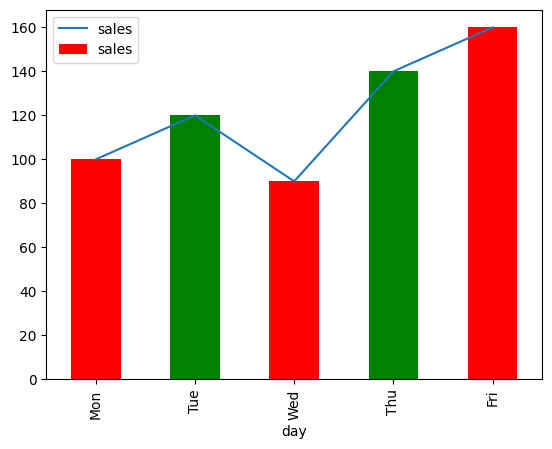

In [37]:
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "day": ["Mon", "Tue", "Wed", "Thu", "Fri"],
    "sales": [100, 120, 90, 140, 160]
})

ax = df.plot(x="day", y="sales", kind="line")
df.plot(x="day", y="sales", kind="bar", ax=ax, color=['red','green'])
plt.show()

In [ ]:
df = pd.DataFrame({
    "region": ["East", "East", "West", "West","South"],
    "sales": [100, 200, 50, 60, 20]
})

# keep groups where total sales > 150
filtered = df.groupby("region").filter(lambda x: x["sales"].sum() > 150)
print(filtered)

  region  sales
0   East    100
1   East    200


In [12]:
import numpy as np
a = [[1,2],[3,4.1]]
b = np.array(a)

In [13]:
b 

array([[1. , 2. ],
       [3. , 4.1]])

In [15]:
list(b)

[array([1., 2.]), array([3. , 4.1])]

In [20]:
np.min(b)

np.float64(1.0)

# Data Analysis and MatPlot Lib with Pandas

In [2]:
!pip install pandas matplotlib numpy seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_sales = pd.read_csv('data/PS4_GamesSales.csv', encoding = 'windows-1252')

In [5]:
df_sales.head()

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80


In [6]:
df_sales.Publisher.nunique()

152

In [7]:
df_sales.describe()

,Year,North America,Europe,Japan,Rest of World,Global
count,825.000000,1034.000000,1034.000000,1034.000000,1034.000000,1034.000000
mean,2015.966061,0.204613,0.248714,0.033636,0.089014,0.576054
std,1.298360,0.563471,0.785491,0.108344,0.249410,1.583534
min,2013.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016.000000,0.020000,0.000000,0.000000,0.010000,0.060000
75%,2017.000000,0.120000,0.130000,0.030000,0.050000,0.357500
max,2020.000000,6.180000,9.710000,2.170000,3.020000,19.390000


In [8]:
df_sales.Year.unique()

array([2014., 2015., 2018., 2017., 2016., 2013.,   nan, 2019., 2020.])

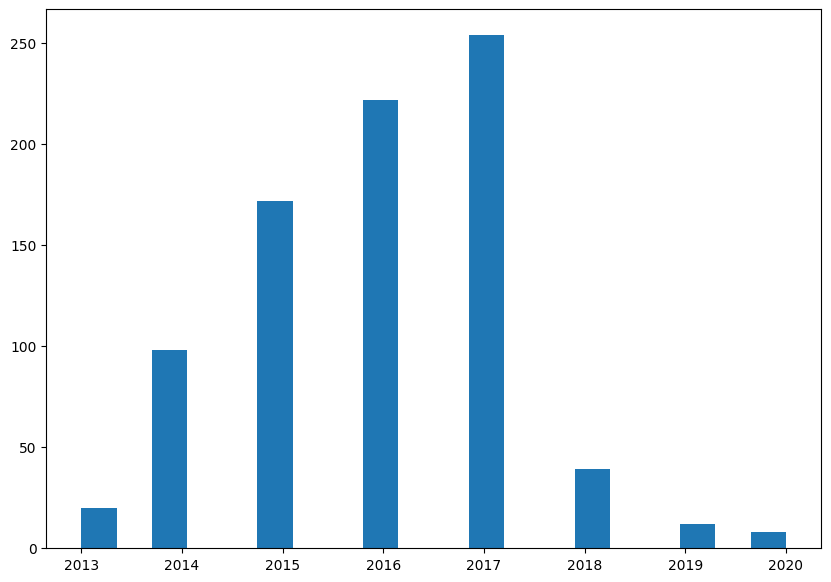

In [23]:
plt.subplots(figsize = (10,7))
plt.hist(df_sales.Year,bins = 20)
plt.show()

In [ ]:
df_rockstar = df_sales.groupby('Publisher').agg({
    'North America'	: ['sum', 'count', 'min', 'max'],
    'Europe': ['sum', 'count', 'min', 'max'],	
    'Japan': ['sum', 'count', 'min', 'max']	,
    'Rest of World': ['sum', 'count', 'min', 'max']	,
    'Global': ['sum', 'count', 'min', 'max']
})

In [14]:
df_rockstar

North America                   Europe  \
                                                 sum count   min   max    sum   
Publisher                                                                       
2K Games                                        2.93     7  0.16  0.72   3.62   
2K Sports                                      10.22     7  0.40  2.56   3.96   
3D Realms                                       0.00     1  0.00  0.00   0.00   
505 Games                                       1.26    16  0.00  0.37   2.21   
5pb                                             0.03     8  0.00  0.03   0.00   
...                                              ...   ...   ...   ...    ...   
Warner Bros. Interactive Entertainment         10.16    27  0.00  1.94  12.88   
Wired Productions                               0.06     3  0.02  0.02   0.00   
Xseed Games                                     0.06     1  0.06  0.06   0.00   
Yacht Club Games                                0.08     1  0.08  0.08   0.04   
Yeti                                            0.00     1  0.00  0.00   0.00   

                                                         Japan              \
                                       count   min   max   sum count   min   
Publisher                                                                    
2K Games                                   7  0.10  1.67  0.18     7  0.00   
2K Sports                                  7  0.35  0.67  0.14     7  0.00   
3D Realms                                  1  0.00  0.00  0.00     1  0.00   
505 Games                                 16  0.00  1.34  0.07    16  0.00   
5pb                                        8  0.00  0.00  0.08     8  0.00   
...                                      ...   ...   ...   ...   ...   ...   
Warner Bros. Interactive Entertainment    27  0.00  1.60  0.30    27  0.00   
Wired Productions                          3  0.00  0.00  0.00     3  0.00   
Xseed Games                                1  0.00  0.00  0.01     1  0.01   
Yacht Club Games                           1  0.04  0.04  0.00     1  0.00   
Yeti                                       1  0.00  0.00  0.03     1  0.03   

                                             Rest of World                    \
                                         max           sum count   min   max   
Publisher                                                                      
2K Games                                0.05          1.28     7  0.05  0.44   
2K Sports                               0.05          3.05     7  0.19  0.71   
3D Realms                               0.00          0.00     1  0.00  0.00   
505 Games                               0.03          0.66    16  0.00  0.31   
5pb                                     0.02          0.01     8  0.00  0.01   
...                                      ...           ...   ...   ...   ...   
Warner Bros. Interactive Entertainment  0.06          4.52    27  0.00  0.61   
Wired Productions                       0.00          0.02     3  0.00  0.01   
Xseed Games                             0.01          0.01     1  0.01  0.01   
Yacht Club Games                        0.00          0.02     1  0.02  0.02   
Yeti                                    0.03          0.00     1  0.00  0.00   

                                       Global                    
                                          sum count   min   max  
Publisher                                                        
2K Games                                 8.03     7  0.31  2.87  
2K Sports                               17.36     7  1.16  3.98  
3D Realms                                0.00     1  0.00  0.00  
505 Games                                4.19    16  0.02  2.02  
5pb                                      0.12     8  0.01  0.04  
...                                       ...   ...   ...   ...  
Warner Bros. Interactive Entertainment  27.83    27  0.00  3.49  
Wired Productions             

In [33]:
df_rockstar.xs('sum', axis=1 , level=1)

,North America,Europe,Japan,Rest of World,Global
Publisher,,,,,
2K Games,2.93,3.62,0.18,1.28,8.03
2K Sports,10.22,3.96,0.14,3.05,17.36
3D Realms,0.00,0.00,0.00,0.00,0.00
505 Games,1.26,2.21,0.07,0.66,4.19
5pb,0.03,0.00,0.08,0.01,0.12
...,...,...,...,...,...
Warner Bros. Interactive Entertainment,10.16,12.88,0.30,4.52,27.83
Wired Productions,0.06,0.00,0.00,0.02,0.08
Xseed Games,0.06,0.00,0.01,0.01,0.08


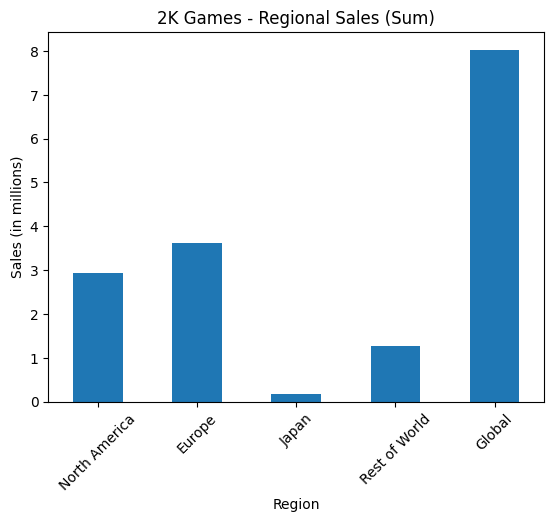

In [32]:
sum_df = df_rockstar.xs('sum', axis=1, level=1)   # selects 'sum' under each region

# Bar plot for a single publisher (e.g., 2K Games)
publisher = "2K Games"
sum_df.loc[publisher].plot(kind="bar")
plt.title(f"{publisher} - Regional Sales (Sum)")
plt.ylabel("Sales (in millions)")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.show()

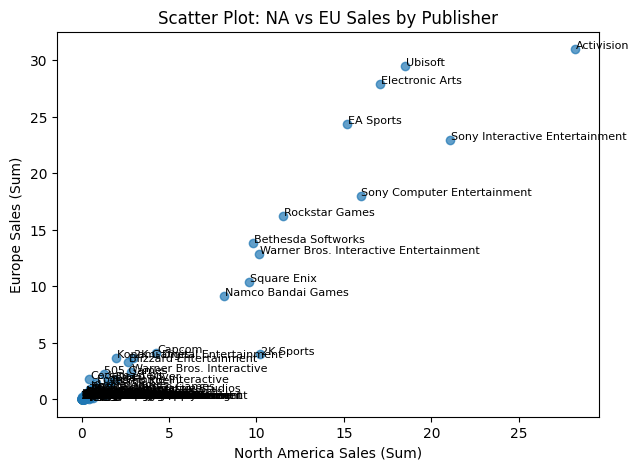

In [19]:
sum_df = df_rockstar.xs('sum', axis=1, level=1)

# Scatter: North America vs Europe
plt.figure(figsize=(7,5))
plt.scatter(sum_df["North America"], sum_df["Europe"], alpha=0.7)

# Annotate points with publisher names
for publisher, row in sum_df.iterrows():
    plt.text(row["North America"]+0.05, row["Europe"]+0.05, publisher, fontsize=8)

plt.xlabel("North America Sales (Sum)")
plt.ylabel("Europe Sales (Sum)")
plt.title("Scatter Plot: NA vs EU Sales by Publisher")
plt.show()


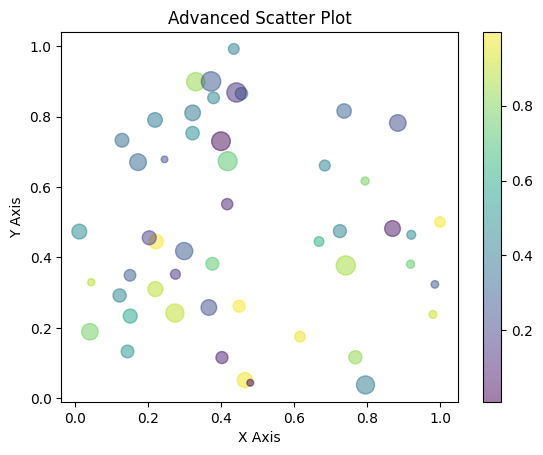

In [3]:

import matplotlib.pyplot as plt 
import numpy as np
#Generating random data
x = np.random.rand(50) 
y = np.random.rand(50) 
sizes = np.random.randint(20, 200, size=50) 
# Random sizes 
colors = np.random.rand(50) 
# Random colors
# #Creating an advanced scatter 
plt.scatter(x, y, s=sizes, c=colors, alpha=0.5, cmap='viridis') 
plt.title('Advanced Scatter Plot') 
plt.xlabel('X Axis') 
plt.ylabel('Y Axis') 
plt.colorbar() 
# Show color scale 
plt.show()

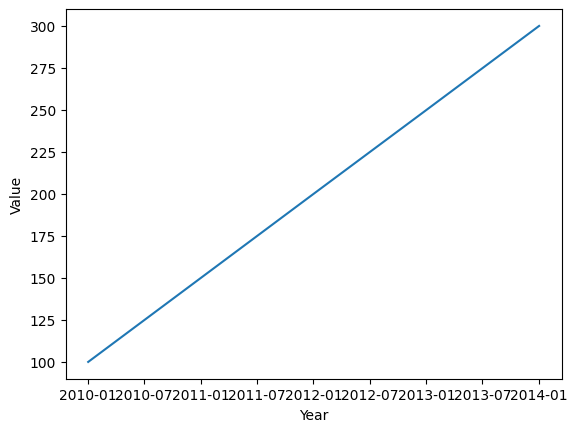

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(
    {
        "Year": ['2010', '2011', '2012', '2013', '2014'], 
        "Value": [100, 150, 200, 250, 300]
    }
)
# df['Year'] = pd.to_datetime(df['Year'] , format='%Y')
sns.lineplot(x="Year", y="Value", data=df)
plt.show()

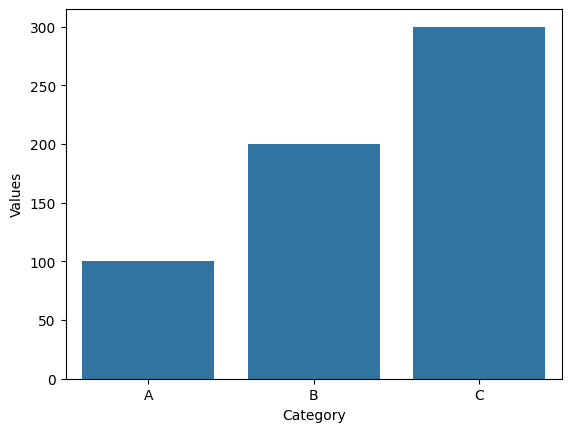

In [13]:
data = pd.DataFrame(
    {
        "Category": ["A", "B", "C"], 
        "Values": [100, 200, 300]
    }
)
sns.barplot(x="Category", y="Values", data=data)
plt.show()

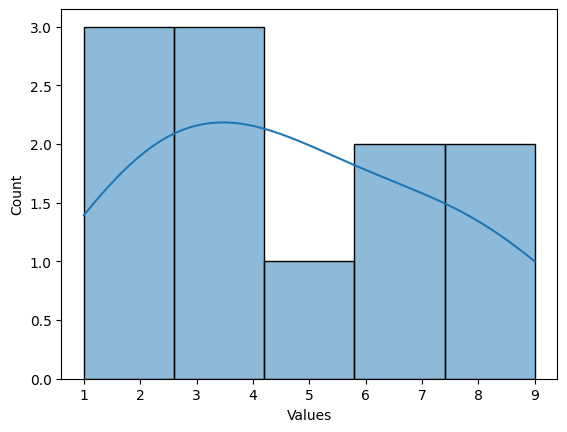

In [18]:
data = pd.DataFrame(
    {
        "Values": [1, 2, 2, 3, 4, 4, 5, 6, 7, 8, 9]
    }
)
sns.histplot(data["Values"], bins=5, kde=True)
plt.show()

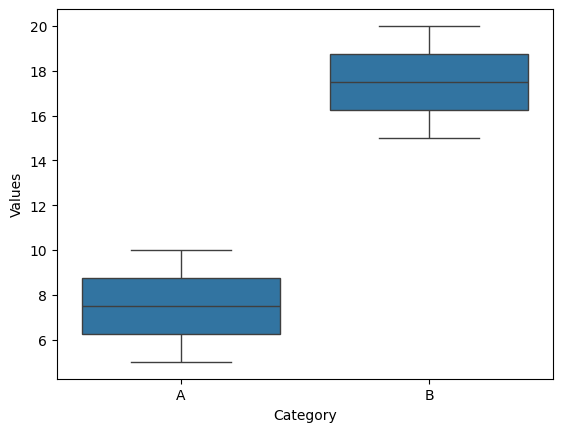

In [ ]:
data = pd.DataFrame(
    {
        "Category": ["A", "A", "B", "B"], 
        "Values": [5, 10, 15, 20]
     }
)
sns.boxplot(x="Category", y="Values", data=data)
plt.show()

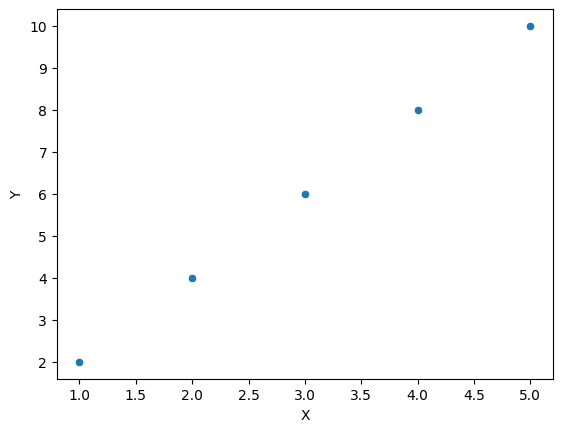

In [ ]:
data = pd.DataFrame(
    {
        "X": [1, 2, 3, 4, 5], 
        "Y": [2, 4, 6, 8, 10]
    }
)
sns.scatterplot(x="X", y="Y", data=data)
plt.show()

In [1]:
!pip install pandas matplotlib seaborn scipy

   ---------------------------------------- 0.0/38.6 MB ? eta -:--:--
    --------------------------------------- 0.8/38.6 MB 4.2 MB/s eta 0:00:10
   - -------------------------------------- 1.6/38.6 MB 4.2 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/38.6 MB 4.2 MB/s eta 0:00:09
   --- ------------------------------------ 3.4/38.6 MB 4.1 MB/s eta 0:00:09
   ---- ----------------------------------- 4.5/38.6 MB 4.4 MB/s eta 0:00:08
   ------ --------------------------------- 6.0/38.6 MB 4.9 MB/s eta 0:00:07
   ------- -------------------------------- 7.1/38.6 MB 5.0 MB/s eta 0:00:07
   --------- ------------------------------ 8.9/38.6 MB 5.4 MB/s eta 0:00:06
   ----------- ---------------------------- 11.0/38.6 MB 6.0 MB/s eta 0:00:05
   ------------- -------------------------- 13.1/38.6 MB 6.4 MB/s eta 0:00:04
   --------------- ------------------------ 14.7/38.6 MB 6.5 MB/s eta 0:00:04
   ----------------- ---------------------- 16.5/38.6 MB 6.7 MB/s eta 0:00:04
  


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


=== DATASET OVERVIEW ===
Dataset shape: (76038, 9)

First 5 rows:
   bhk       type                              locality  area  price  \
0    3  Apartment   Lak And Hanware The Residency Tower   685   2.50   
1    2  Apartment     Radheya Sai Enclave Building No 2   640  52.51   
2    2  Apartment                         Romell Serene   610   1.73   
3    2  Apartment  Soundlines Codename Urban Rainforest   876  59.98   
4    2  Apartment                         Origin Oriana   659  94.11   

  price_unit          region              status  age  
0         Cr    Andheri West       Ready to move  New  
1          L    Naigaon East  Under Construction  New  
2         Cr   Borivali West  Under Construction  New  
3          L          Panvel  Under Construction  New  
4          L  Mira Road East  Under Construction  New  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
-

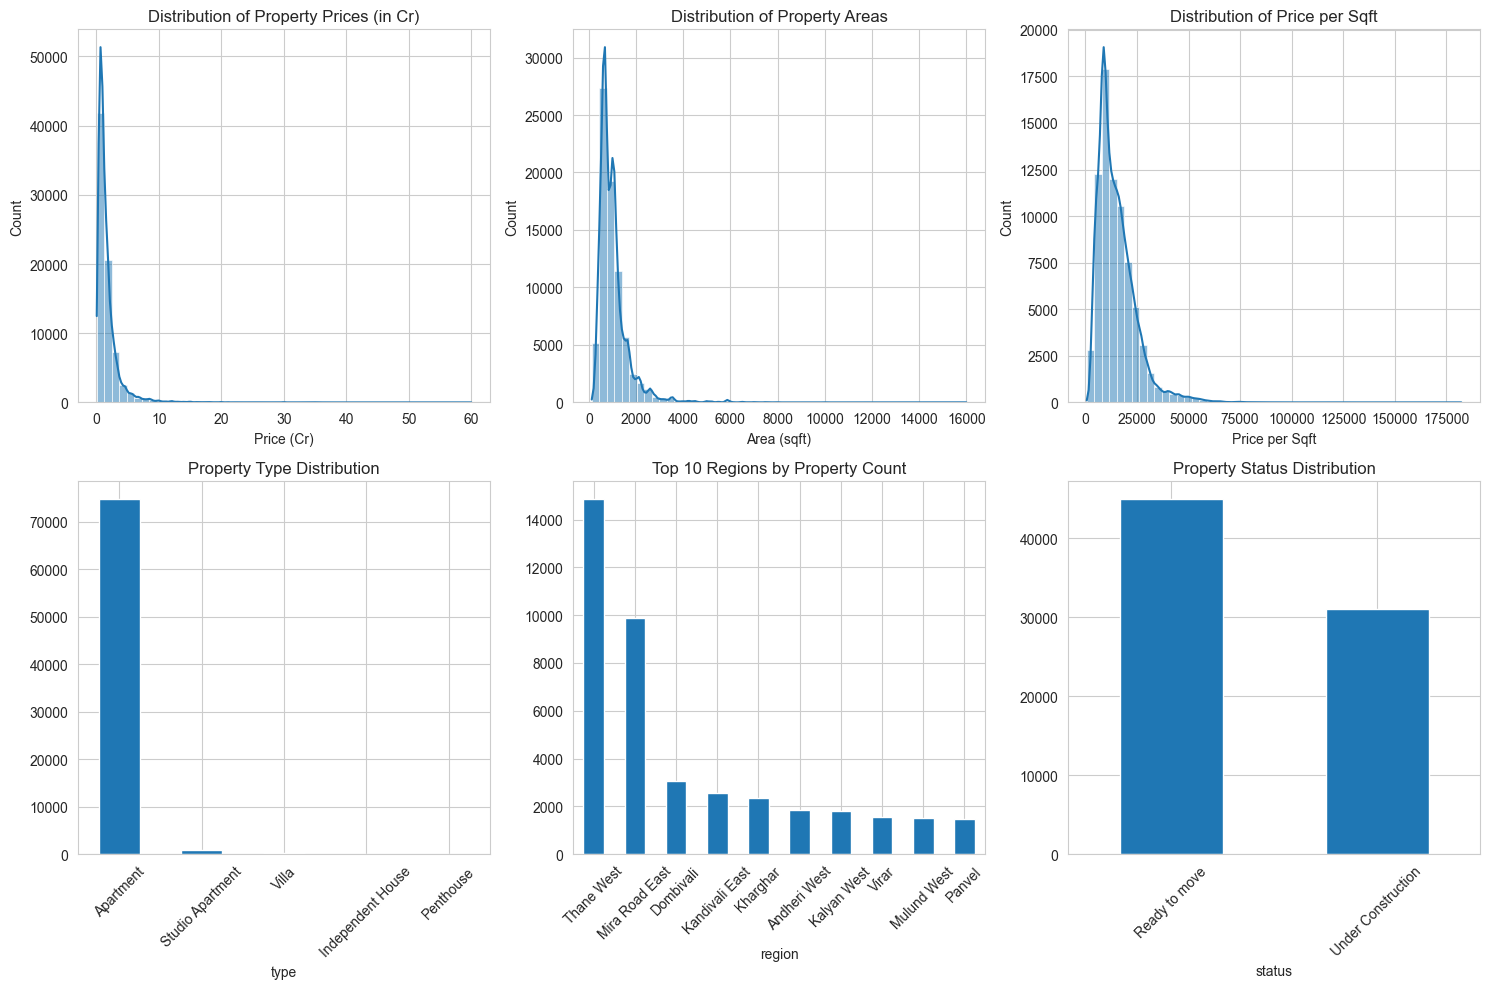

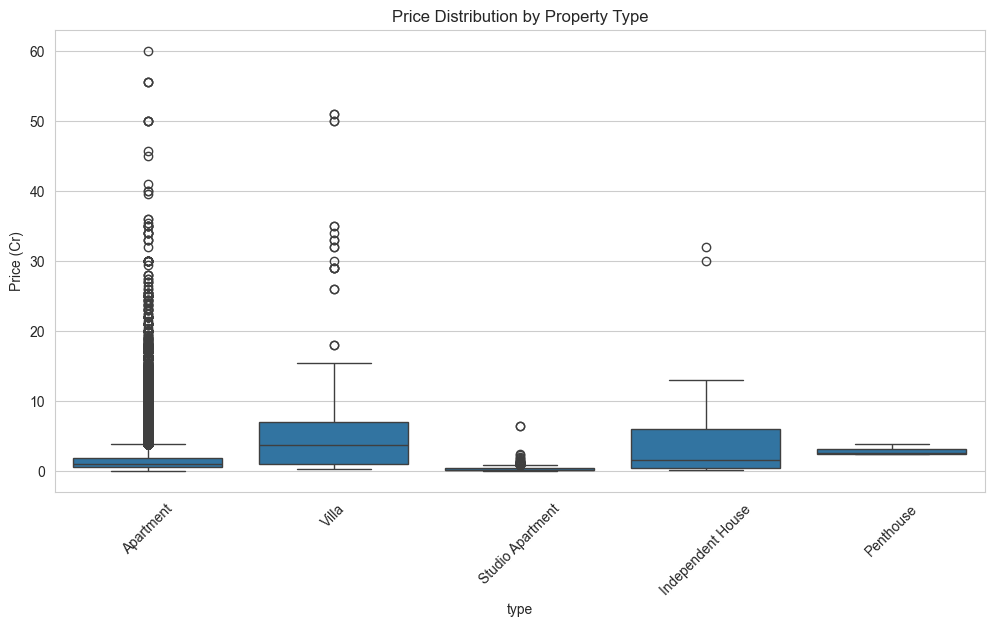

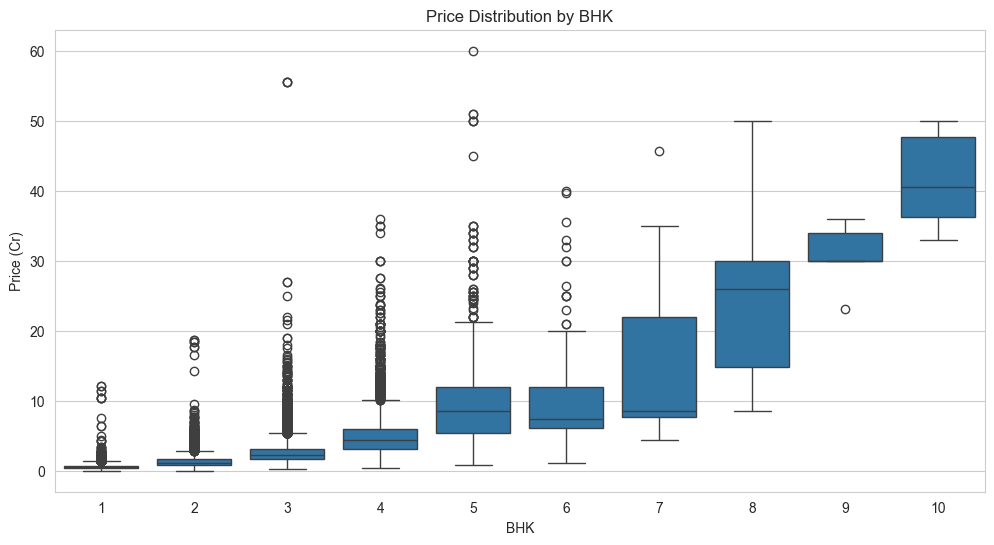

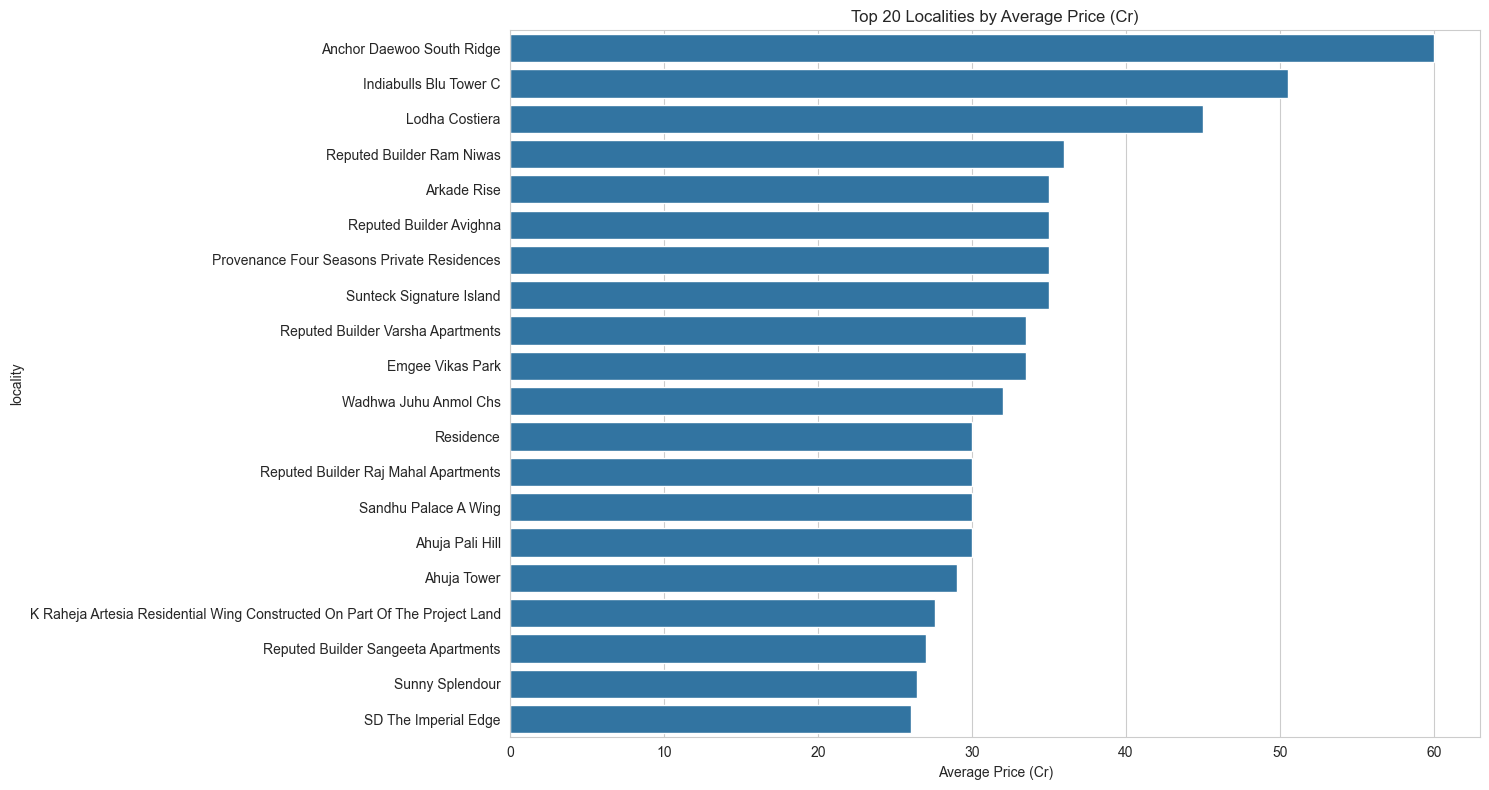

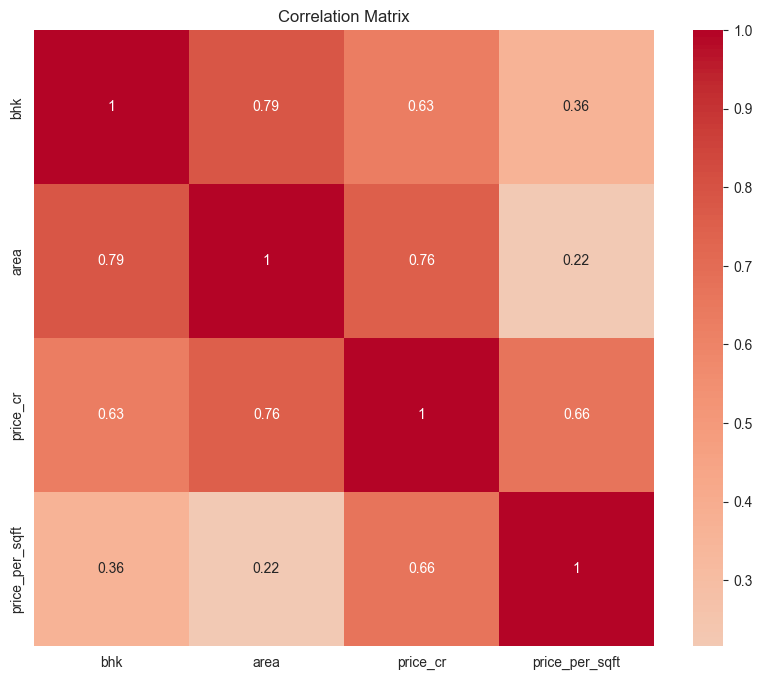

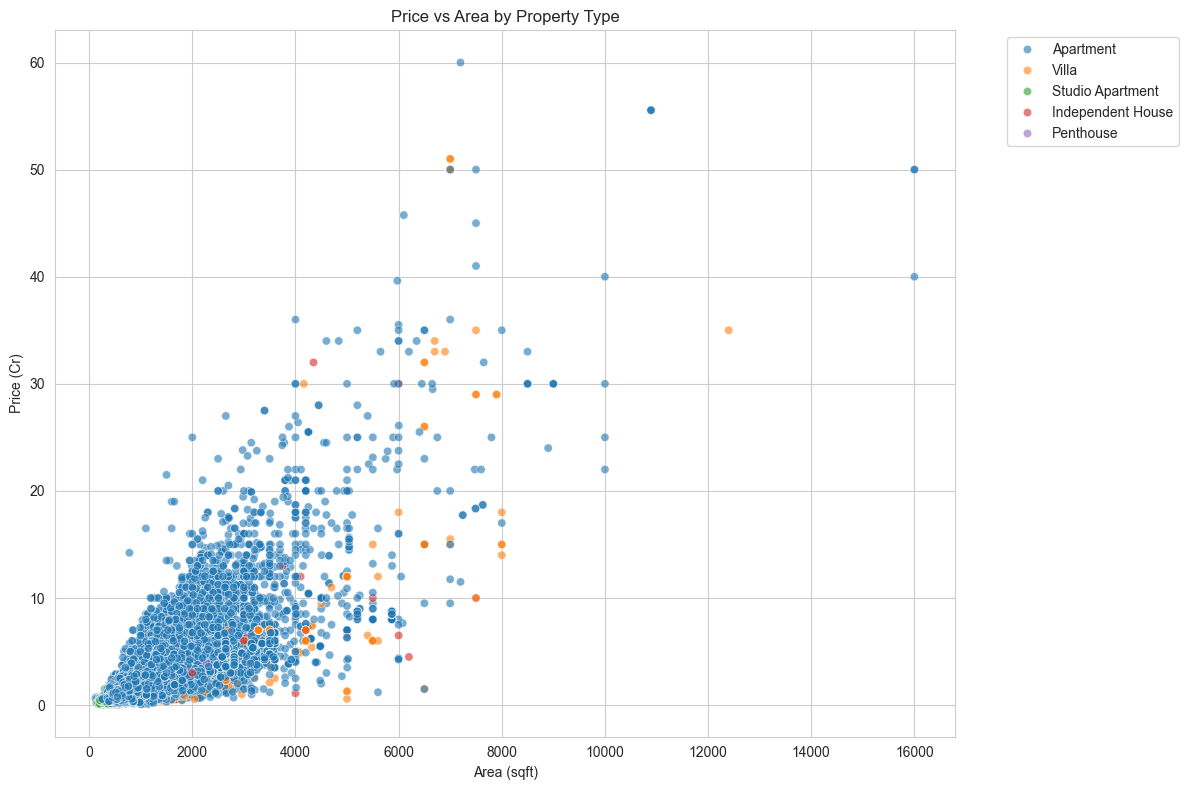

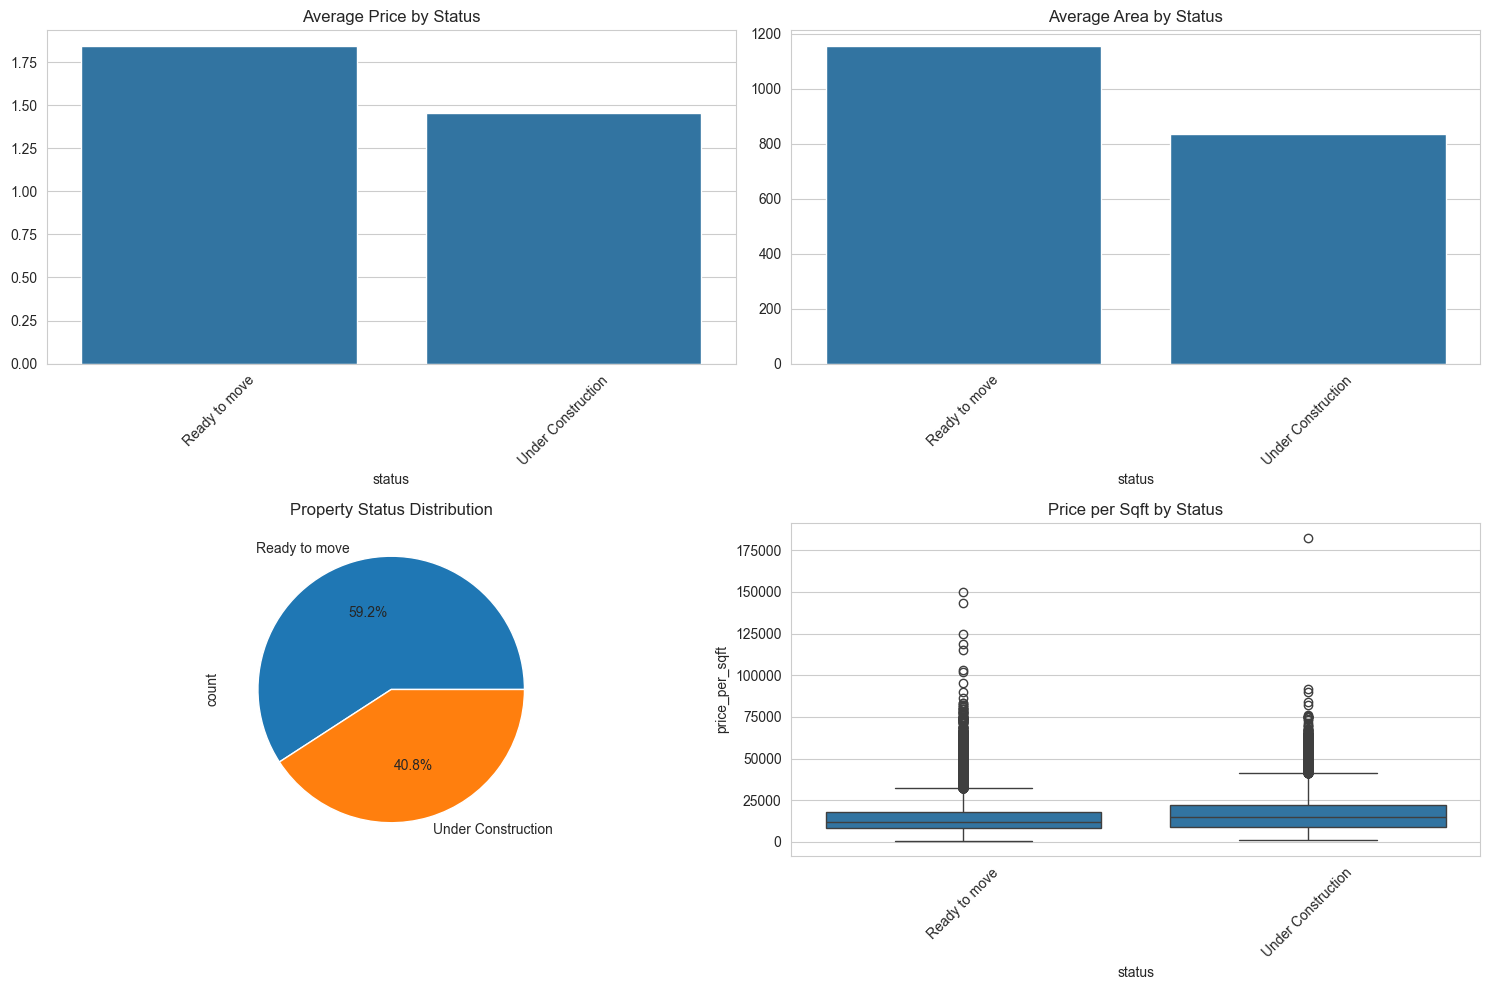

=== BHK-WISE ANALYSIS ===
    price_cr                                  area          price_per_sqft  \
       count   mean median    min    max      mean   median           mean   
bhk                                                                          
1      24613   0.63   0.58   0.04  12.07    582.96    600.0       11331.62   
2      31429   1.32   1.18   0.06  18.69    912.65    935.0       15012.10   
3      15273   2.70   2.30   0.23  55.55   1436.00   1400.0       19099.20   
4       3934   5.35   4.50   0.39  36.00   2426.81   2350.0       22151.04   
5        606  10.34   8.50   0.90  60.00   4248.90   4200.0       24772.91   
6        148  10.25   7.42   1.10  40.00   3965.51   4200.0       25273.42   
7         16  15.83   8.60   4.50  45.75   5033.19   4300.0       30690.78   
8          8  24.61  26.00   8.50  50.00   6085.62   6025.0       39282.32   
9          5  30.63  30.00  23.13  36.00   6670.00   6350.0       46464.11   
10         6  41.50  40.50  33.00  50.

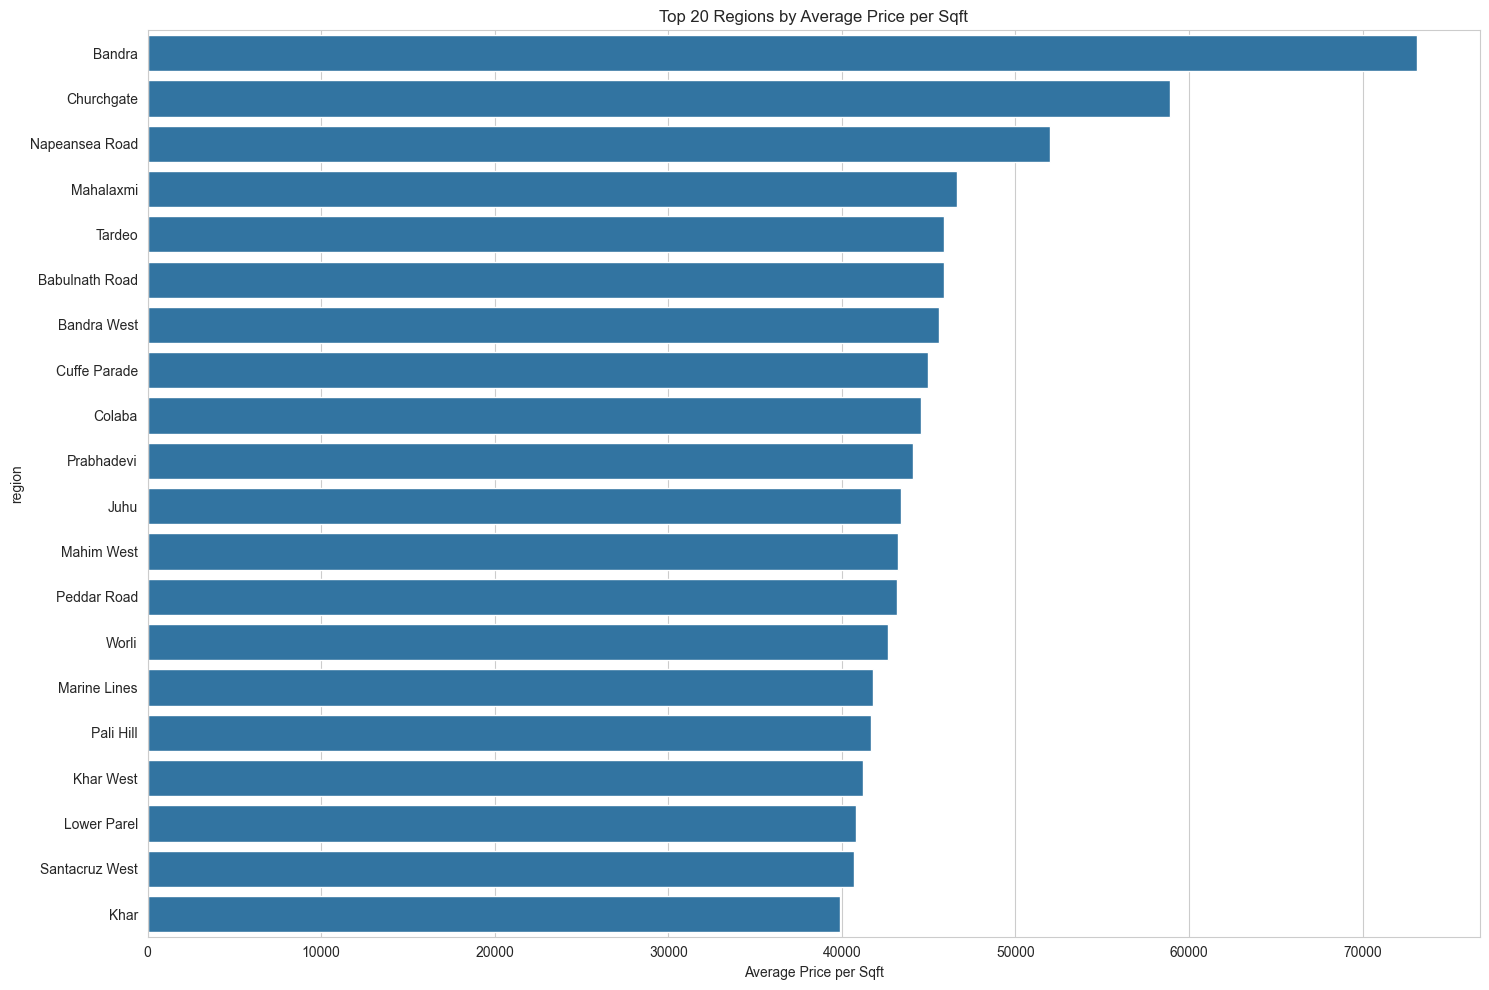


=== OUTLIER ANALYSIS ===
Number of outliers in price per sqft: 2543
Outlier percentage: 3.34%


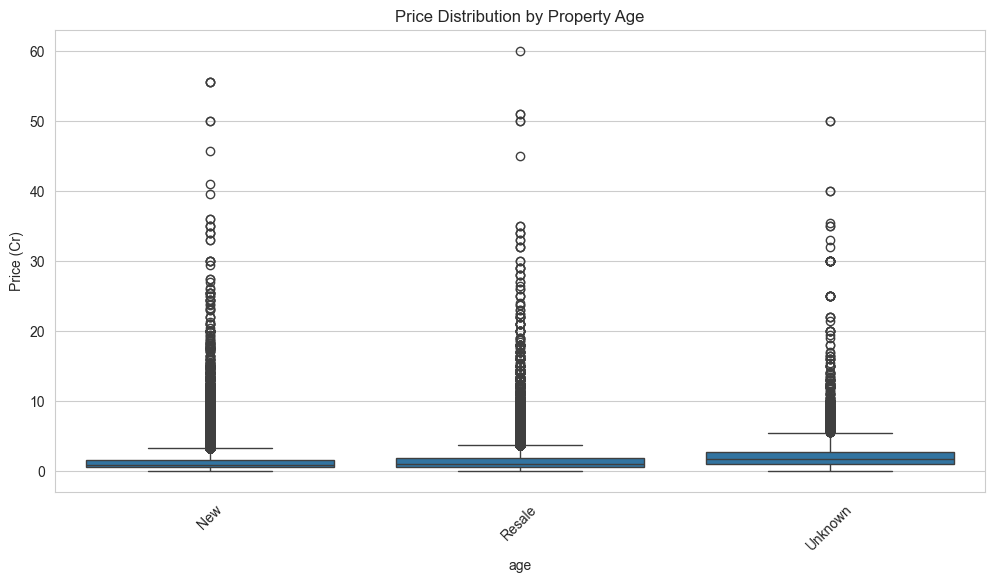


=== TOP 10 MOST EXPENSIVE PROPERTIES ===
                                  locality         region      type  bhk  area  price_cr  price_per_sqft
                 Anchor Daewoo South Ridge Napeansea Road Apartment    5  7200     60.00    83333.333333
                Rustomjee Paramount Wing F Santacruz West Apartment    3 10893     55.55    50996.052511
                Rustomjee Paramount Wing F Santacruz West Apartment    3 10893     55.55    50996.052511
                Rustomjee Paramount Wing F Santacruz West Apartment    3 10893     55.55    50996.052511
                    Indiabulls Blu Tower C          Worli     Villa    5  7000     51.00    72857.142857
                    Indiabulls Blu Tower C          Worli     Villa    5  7000     51.00    72857.142857
                    Indiabulls Blu Tower C          Worli     Villa    5  7000     50.00    71428.571429
                    Indiabulls Blu Tower C          Worli     Villa    5  7000     50.00    71428.571429
Provenance Fo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load the dataset
df = pd.read_csv('data/Mumbai House Prices.csv')

# Display basic information about the dataset
print("=== DATASET OVERVIEW ===")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

# Check for missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# Data Preprocessing
# Convert price to a common unit (convert Lakhs to Crores for consistency)
def convert_price(row):
    if row['price_unit'] == 'L':
        return row['price'] / 100  # Convert Lakhs to Crores
    else:
        return row['price']

df['price_cr'] = df.apply(convert_price, axis=1)

# Calculate price per square foot
df['price_per_sqft'] = df['price_cr'] * 10000000 / df['area']  # Convert Cr to rupees and divide by area

print("\n=== DATA AFTER CONVERSION ===")
print(f"Price range: {df['price_cr'].min():.2f} Cr to {df['price_cr'].max():.2f} Cr")
print(f"Area range: {df['area'].min()} sqft to {df['area'].max()} sqft")

# Exploratory Data Analysis

# 1. Price Distribution
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['price_cr'], bins=50, kde=True)
plt.title('Distribution of Property Prices (in Cr)')
plt.xlabel('Price (Cr)')

plt.subplot(2, 3, 2)
sns.histplot(df['area'], bins=50, kde=True)
plt.title('Distribution of Property Areas')
plt.xlabel('Area (sqft)')

plt.subplot(2, 3, 3)
sns.histplot(df['price_per_sqft'], bins=50, kde=True)
plt.title('Distribution of Price per Sqft')
plt.xlabel('Price per Sqft')

# 2. Categorical Variables Analysis
plt.subplot(2, 3, 4)
df['type'].value_counts().plot(kind='bar')
plt.title('Property Type Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
df['region'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Regions by Property Count')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
df['status'].value_counts().plot(kind='bar')
plt.title('Property Status Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. Price by Property Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='type', y='price_cr')
plt.title('Price Distribution by Property Type')
plt.xticks(rotation=45)
plt.ylabel('Price (Cr)')
plt.show()

# 4. Price by BHK
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bhk', y='price_cr')
plt.title('Price Distribution by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Cr)')
plt.show()

# 5. Top 20 Localities by Average Price
top_localities = df.groupby('locality')['price_cr'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(15, 8))
sns.barplot(x=top_localities.values, y=top_localities.index)
plt.title('Top 20 Localities by Average Price (Cr)')
plt.xlabel('Average Price (Cr)')
plt.tight_layout()
plt.show()

# 6. Correlation Analysis
# Select numerical columns for correlation
numerical_cols = ['bhk', 'area', 'price_cr', 'price_per_sqft']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# 7. Price vs Area Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='area', y='price_cr', hue='type', alpha=0.6)
plt.title('Price vs Area by Property Type')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (Cr)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 8. Status-wise Analysis
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
status_price = df.groupby('status')['price_cr'].mean().sort_values(ascending=False)
sns.barplot(x=status_price.index, y=status_price.values)
plt.title('Average Price by Status')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
status_area = df.groupby('status')['area'].mean().sort_values(ascending=False)
sns.barplot(x=status_area.index, y=status_area.values)
plt.title('Average Area by Status')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
df['status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Property Status Distribution')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='status', y='price_per_sqft')
plt.title('Price per Sqft by Status')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 9. BHK-wise detailed analysis
bhk_analysis = df.groupby('bhk').agg({
    'price_cr': ['count', 'mean', 'median', 'min', 'max'],
    'area': ['mean', 'median'],
    'price_per_sqft': ['mean', 'median']
}).round(2)

print("=== BHK-WISE ANALYSIS ===")
print(bhk_analysis)

# 10. Region-wise analysis (Top 15 regions)
region_analysis = df.groupby('region').agg({
    'price_cr': ['count', 'mean', 'median'],
    'area': ['mean'],
    'price_per_sqft': ['mean']
}).round(2).sort_values(('price_cr', 'mean'), ascending=False).head(15)

print("\n=== TOP 15 REGIONS BY AVERAGE PRICE ===")
print(region_analysis)

# 11. Price per sqft by region (Top 20)
plt.figure(figsize=(15, 10))
region_pps = df.groupby('region')['price_per_sqft'].mean().sort_values(ascending=False).head(20)
sns.barplot(x=region_pps.values, y=region_pps.index)
plt.title('Top 20 Regions by Average Price per Sqft')
plt.xlabel('Average Price per Sqft')
plt.tight_layout()
plt.show()

# 12. Outlier detection using IQR method for price per sqft
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]
print(f"\n=== OUTLIER ANALYSIS ===")
print(f"Number of outliers in price per sqft: {len(outliers)}")
print(f"Outlier percentage: {len(outliers)/len(df)*100:.2f}%")

# 13. Price trends by property age
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='age', y='price_cr')
plt.title('Price Distribution by Property Age')
plt.xticks(rotation=45)
plt.ylabel('Price (Cr)')
plt.show()

# 14. Most expensive properties
print("\n=== TOP 10 MOST EXPENSIVE PROPERTIES ===")
expensive_properties = df.nlargest(10, 'price_cr')[['locality', 'region', 'type', 'bhk', 'area', 'price_cr', 'price_per_sqft']]
print(expensive_properties.to_string(index=False))

# 15. Affordable properties (price < 1 Cr)
affordable = df[df['price_cr'] < 1]
print(f"\n=== AFFORDABLE PROPERTIES (Price < 1 Cr) ===")
print(f"Count: {len(affordable)}")
print(f"Percentage: {len(affordable)/len(df)*100:.2f}%")

# Summary Statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Total properties: {len(df)}")
print(f"Average price: {df['price_cr'].mean():.2f} Cr")
print(f"Median price: {df['price_cr'].median():.2f} Cr")
print(f"Average area: {df['area'].mean():.2f} sqft")
print(f"Average price per sqft: {df['price_per_sqft'].mean():.2f}")
print(f"Most common property type: {df['type'].mode().iloc[0]}")
print(f"Most common region: {df['region'].mode().iloc[0]}")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# Load the dataset
df = pd.read_csv('data/Mumbai House Prices.csv')

# Display basic information about the dataset
print("=== DATASET OVERVIEW ===")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

=== DATASET OVERVIEW ===
Dataset shape: (76038, 9)

First 5 rows:
   bhk       type                              locality  area  price  \
0    3  Apartment   Lak And Hanware The Residency Tower   685   2.50   
1    2  Apartment     Radheya Sai Enclave Building No 2   640  52.51   
2    2  Apartment                         Romell Serene   610   1.73   
3    2  Apartment  Soundlines Codename Urban Rainforest   876  59.98   
4    2  Apartment                         Origin Oriana   659  94.11   

  price_unit          region              status  age  
0         Cr    Andheri West       Ready to move  New  
1          L    Naigaon East  Under Construction  New  
2         Cr   Borivali West  Under Construction  New  
3          L          Panvel  Under Construction  New  
4          L  Mira Road East  Under Construction  New  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
-

In [4]:
# Check for missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== MISSING VALUES ===
bhk           0
type          0
locality      0
area          0
price         0
price_unit    0
region        0
status        0
age           0
dtype: int64


In [5]:
df.head()

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [6]:
# Convert price to a common unit (convert Lakhs to Crores for consistency)
def convert_price(row):
    if row['price_unit'] == 'L':
        return row['price'] / 100  # Convert Lakhs to Crores
    else:
        return row['price']
    
df['price_cr'] = df.apply(convert_price, axis=1)

In [7]:
# Calculate price per square foot
df['price_per_sqft'] = df['price_cr'] * 10000000 / df['area']  
# Convert Cr to rupees and divide by area


In [8]:
print("\n=== DATA AFTER CONVERSION ===")
print(f"Price range: {df['price_cr'].min():.2f} Cr to {df['price_cr'].max():.2f} Cr")
print(f"Area range: {df['area'].min()} sqft to {df['area'].max()} sqft")



=== DATA AFTER CONVERSION ===
Price range: 0.04 Cr to 60.00 Cr
Area range: 127 sqft to 16000 sqft


#### Exploratory Data Analysis

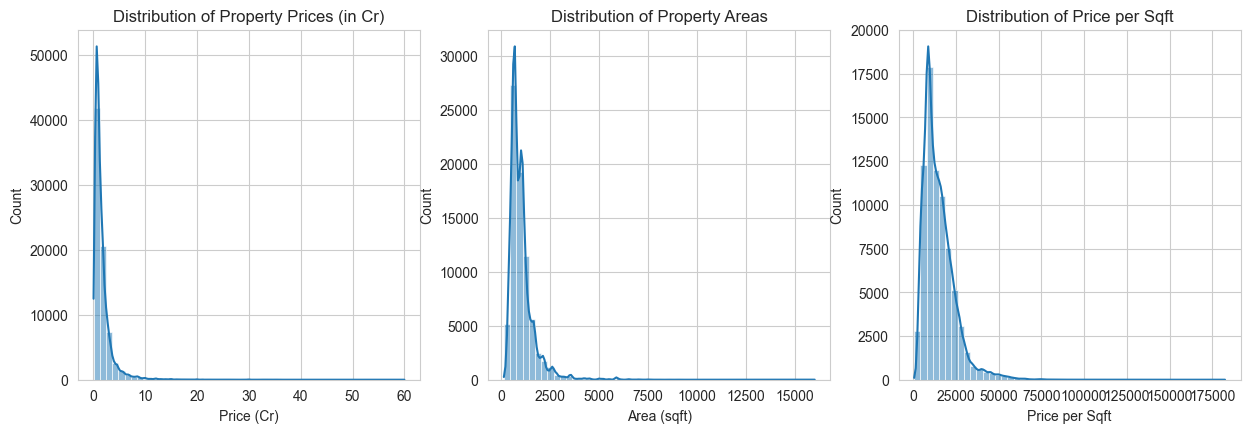

In [9]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['price_cr'], bins=50, kde=True)
plt.title('Distribution of Property Prices (in Cr)')
plt.xlabel('Price (Cr)')

plt.subplot(2, 3, 2)
sns.histplot(df['area'], bins=50, kde=True)
plt.title('Distribution of Property Areas')
plt.xlabel('Area (sqft)')

plt.subplot(2, 3, 3)
sns.histplot(df['price_per_sqft'], bins=50, kde=True)
plt.title('Distribution of Price per Sqft')
plt.xlabel('Price per Sqft')
plt.show()

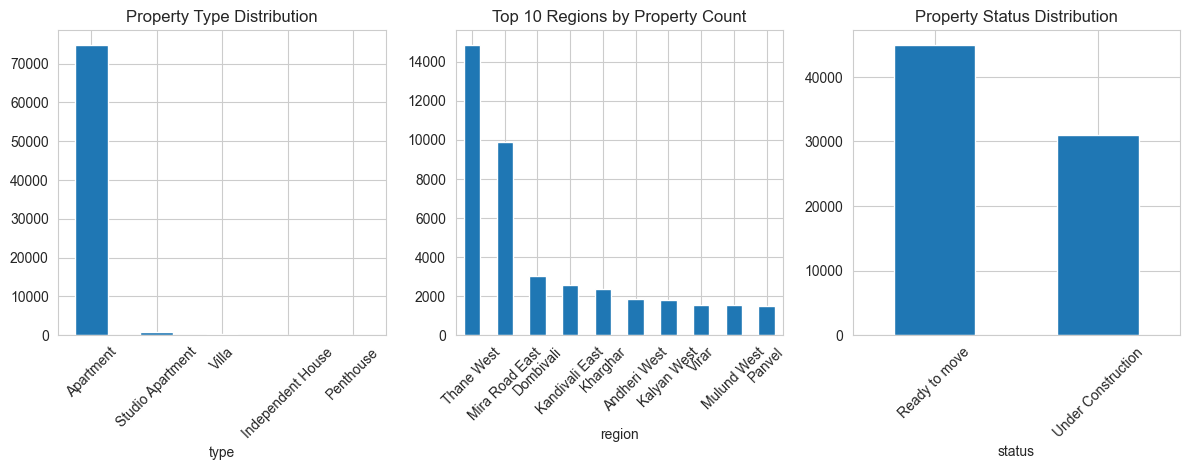

In [10]:
# 2. Categorical Variables Analysis
plt.subplot(2, 3, 4)
df['type'].value_counts().plot(kind='bar')
plt.title('Property Type Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
df['region'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Regions by Property Count')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
df['status'].value_counts().plot(kind='bar')
plt.title('Property Status Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

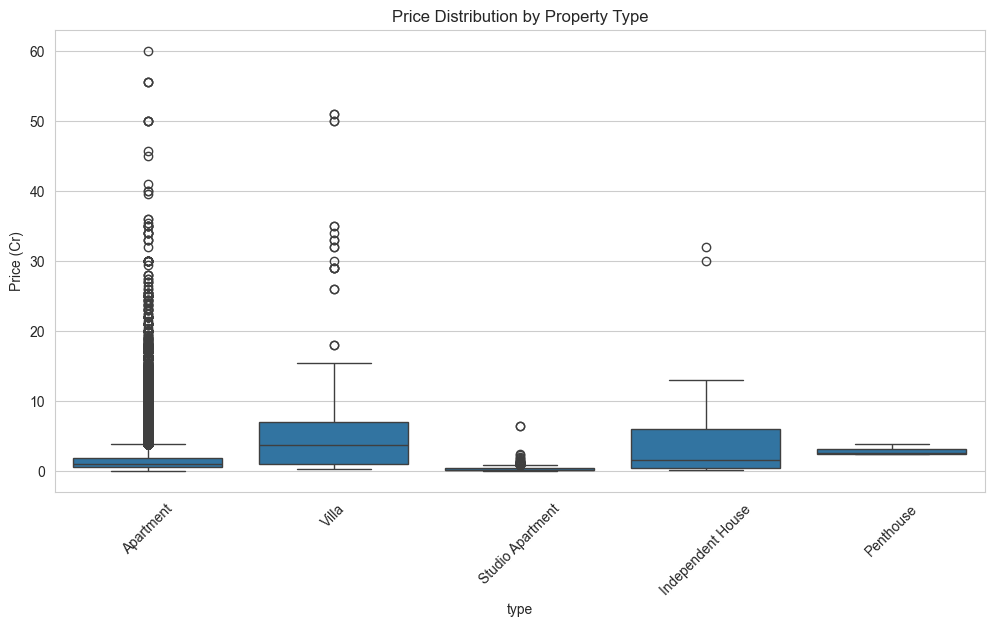

In [11]:
# 3. Price by Property Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='type', y='price_cr')
plt.title('Price Distribution by Property Type')
plt.xticks(rotation=45)
plt.ylabel('Price (Cr)')
plt.show()

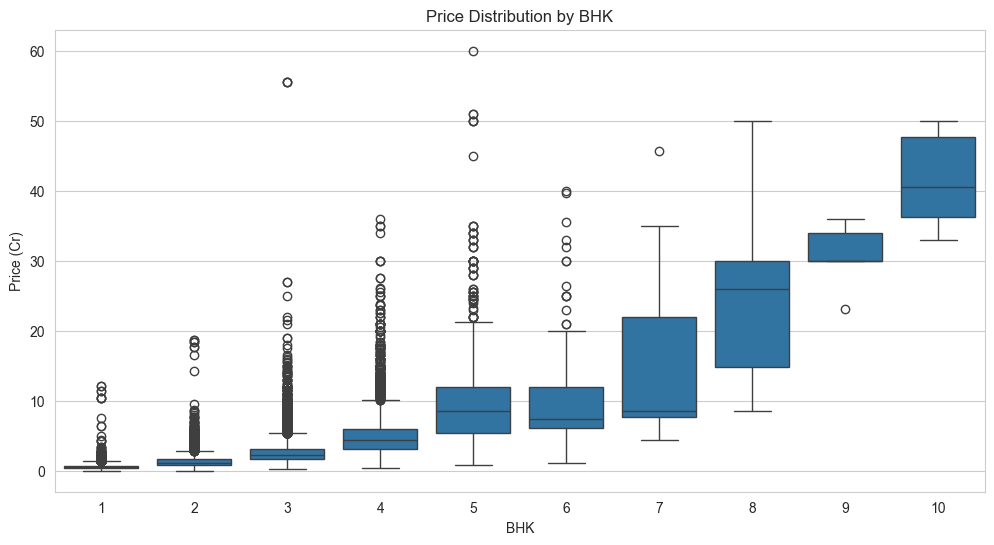

In [12]:
# 4. Price by BHK
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bhk', y='price_cr')
plt.title('Price Distribution by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Cr)')
plt.show()

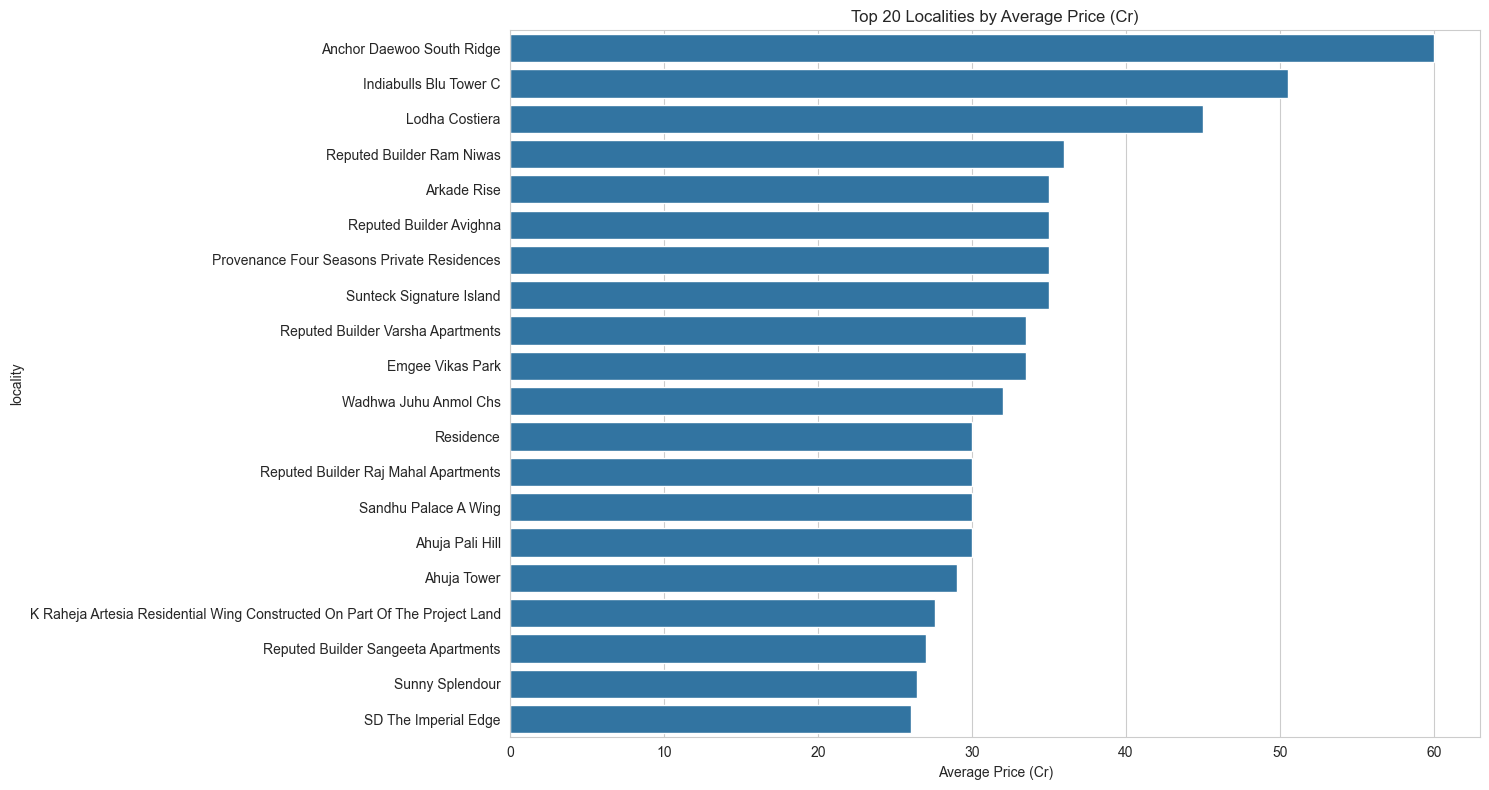

In [13]:
# 5. Top 20 Localities by Average Price
top_localities = df.groupby('locality')['price_cr'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(15, 8))
sns.barplot(x=top_localities.values, y=top_localities.index)
plt.title('Top 20 Localities by Average Price (Cr)')
plt.xlabel('Average Price (Cr)')
plt.tight_layout()
plt.show()

In [15]:
# 6. Correlation Analysis
# Select numerical columns for correlation
numerical_cols = ['bhk', 'area', 'price_cr', 'price_per_sqft']
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,bhk,area,price_cr,price_per_sqft
bhk,1.000000,0.787738,0.631353,0.362950
area,0.787738,1.000000,0.756000,0.216128
price_cr,0.631353,0.756000,1.000000,0.664473
price_per_sqft,0.362950,0.216128,0.664473,1.000000


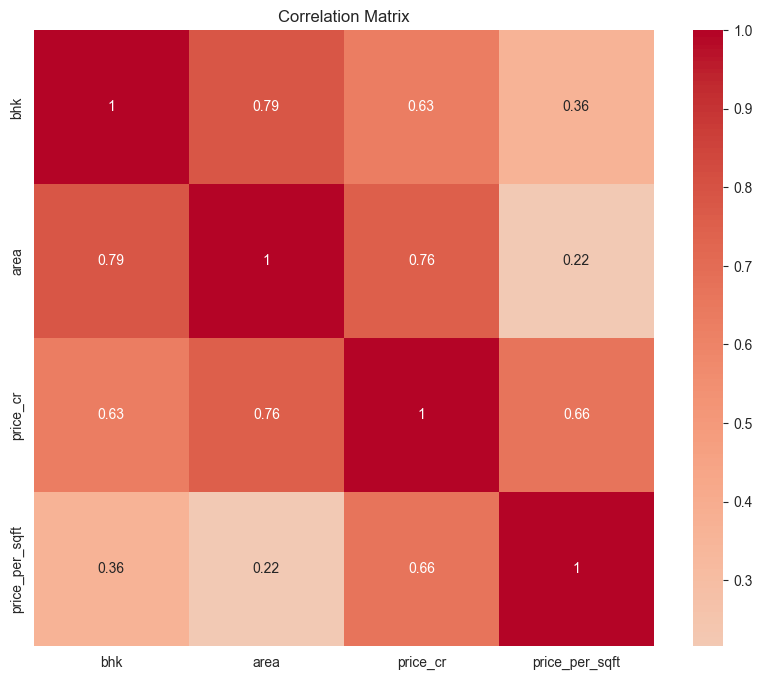

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

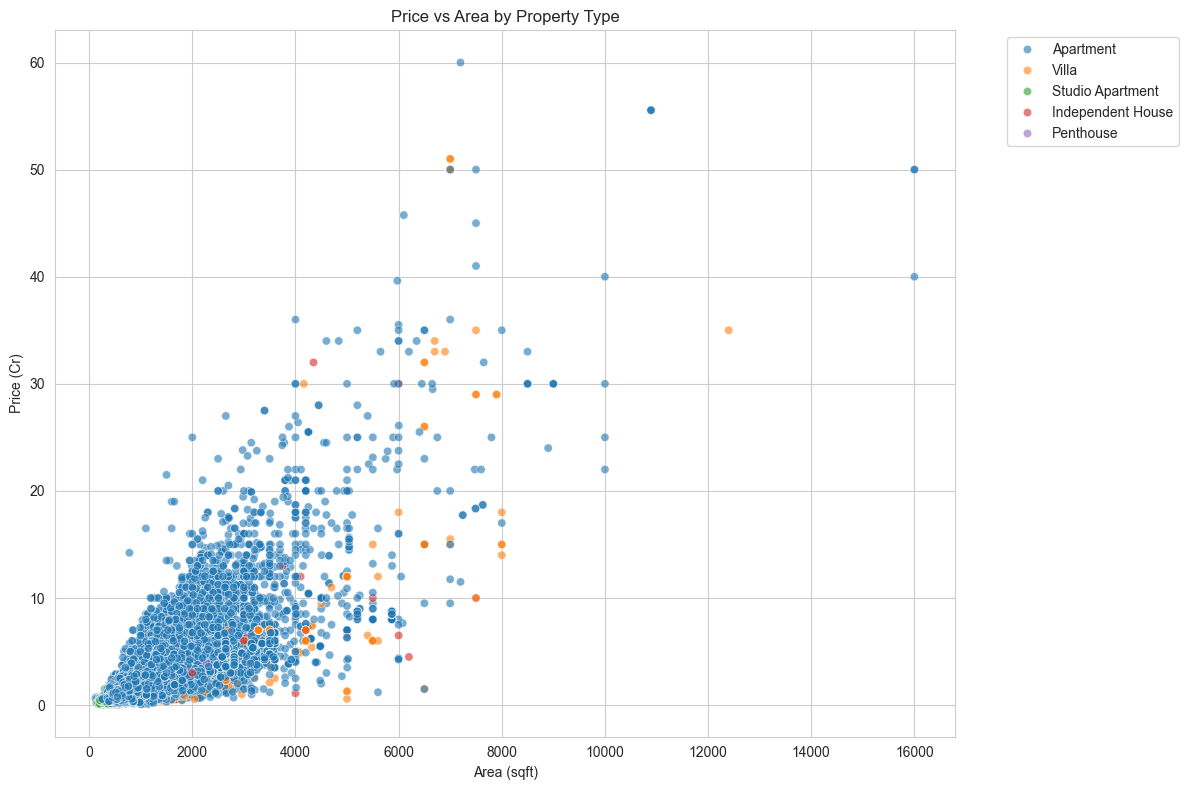

In [17]:
# 7. Price vs Area Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='area', y='price_cr', hue='type', alpha=0.6)
plt.title('Price vs Area by Property Type')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (Cr)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [20]:
df.head()

,bhk,type,locality,area,price,price_unit,region,status,age,price_cr,price_per_sqft
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New,2.5000,36496.350365
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New,0.5251,8204.687500
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New,1.7300,28360.655738
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New,0.5998,6847.031963
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New,0.9411,14280.728376


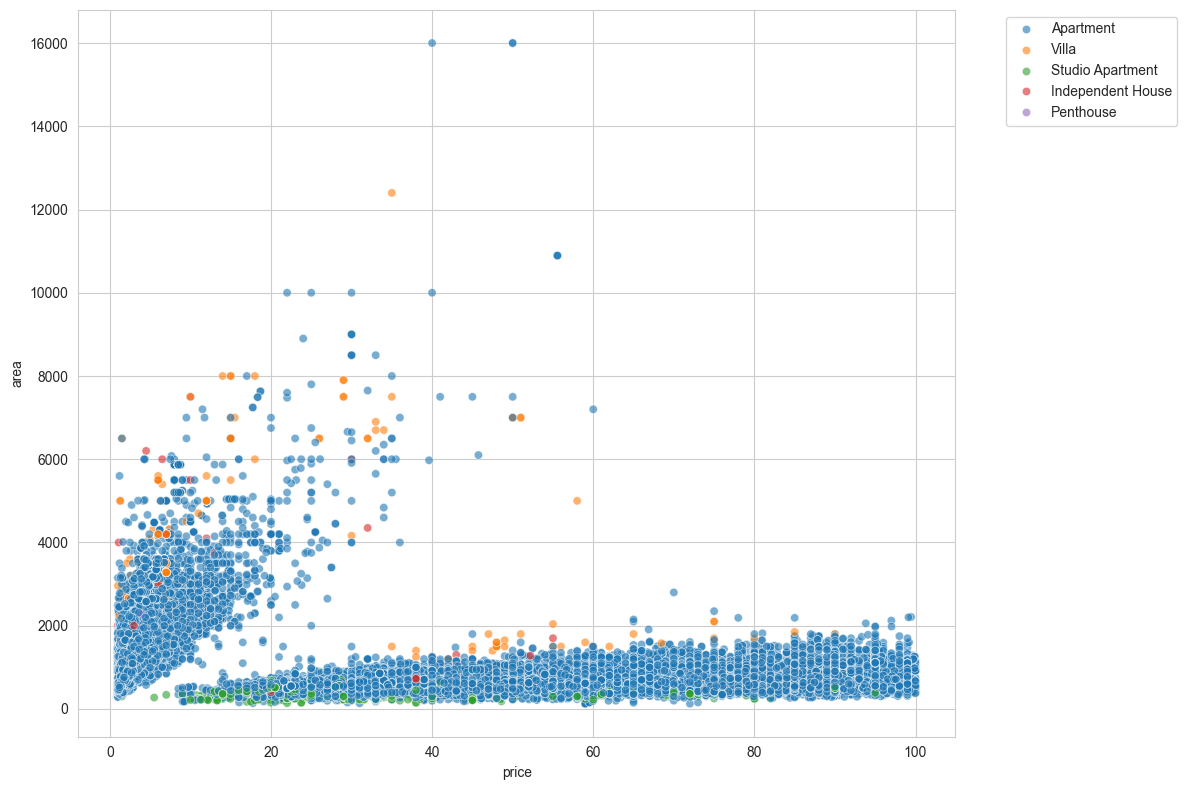

In [24]:
# 7. Price vs Area Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='price', y='area', hue='type', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


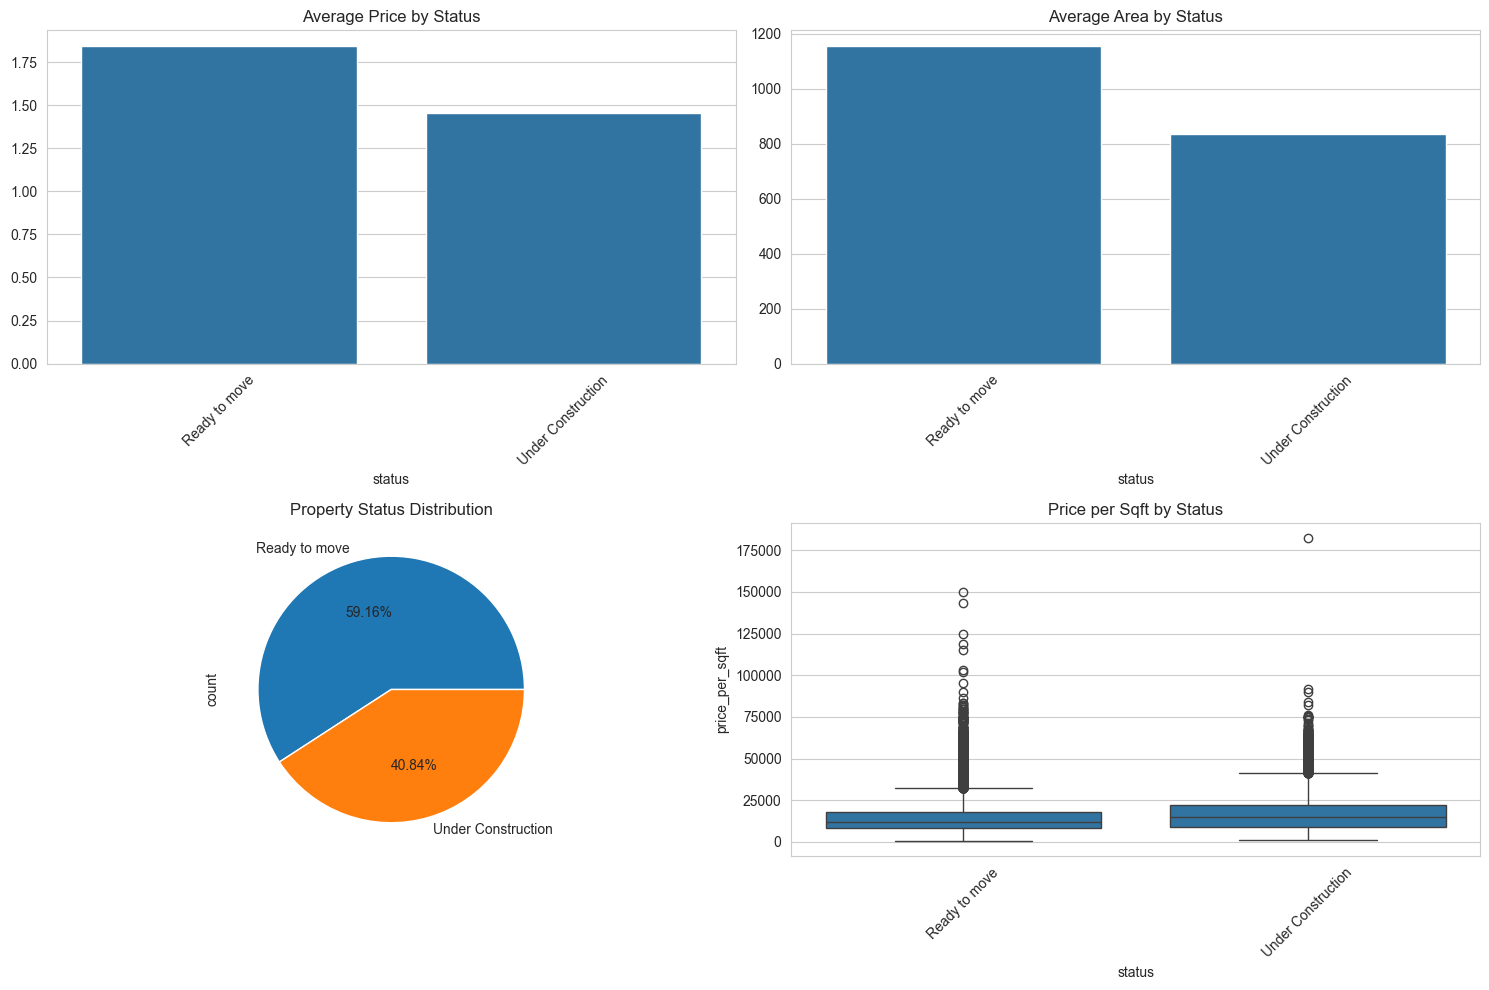

In [31]:
# 8. Status-wise Analysis
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
status_price = df.groupby('status').price_cr.mean().sort_values(ascending=False)
sns.barplot(x=status_price.index, y=status_price.values)
plt.title('Average Price by Status')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
status_area = df.groupby('status').area.mean().sort_values(ascending=False)
sns.barplot(x=status_area.index, y=status_area.values)
plt.title('Average Area by Status')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
df['status'].value_counts().plot(kind='pie', autopct='%.2f%%')
# 1.1 , 0.1f, .2f , 1.0f, 
plt.title('Property Status Distribution')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='status', y='price_per_sqft')
plt.title('Price per Sqft by Status')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
# 12. Outlier detection using IQR method for price per sqft
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]
print(f"\n=== OUTLIER ANALYSIS ===")
print(df.shape)
print(f"Number of outliers in price per sqft: {len(outliers)}")
print(f"Outlier percentage: {len(outliers)/len(df)*100:.2f}%")


=== OUTLIER ANALYSIS ===
(76038, 11)
Number of outliers in price per sqft: 2543
Outlier percentage: 3.34%


In [42]:
# Summary Statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Total properties: {len(df)}")
print(f"Average price: {df['price_cr'].mean():.2f} Cr")
print(f"Median price: {df['price_cr'].median():.2f} Cr")
print(f"Average area: {df['area'].mean():.2f} sqft")
print(f"Average price per sqft: {df['price_per_sqft'].mean():.2f}")
print(f"Most common property type: {df['type'].mode().iloc[0]}")
print(f"Most common region: {df['region'].mode().iloc[0]}")


=== SUMMARY STATISTICS ===
Total properties: 76038
Average price: 1.68 Cr
Median price: 1.10 Cr
Average area: 1024.54 sqft
Average price per sqft: 15118.81
Most common property type: Apartment
Most common region: Thane West


In [45]:
df[['price_cr','price']]

,price_cr,price
0,2.5000,2.50
1,0.5251,52.51
2,1.7300,1.73
3,0.5998,59.98
4,0.9411,94.11
...,...,...
76033,7.0000,7.00
76034,12.0000,12.00
76035,10.0000,10.00
76036,4.2500,4.25


In Python, **`map`**, **`filter`**, and **`reduce`** are functional programming tools that let you process iterables in a clean and expressive way.

---

## 1. `map(function, iterable)`

Applies a function to **each element** of an iterable and returns a map object (which can be converted to list/tuple/etc.).

```python
# Example: Square each number
nums = [1, 2, 3, 4, 5]
squared = list(map(lambda x: x**2, nums))
print(squared)  # [1, 4, 9, 16, 25]
```

---

## 2. `filter(function, iterable)`

Filters elements of an iterable using a **boolean function** (returns only elements for which the function is `True`).

```python
# Example: Keep only even numbers
nums = [1, 2, 3, 4, 5, 6]
evens = list(filter(lambda x: x % 2 == 0, nums))
print(evens)  # [2, 4, 6]
```

---

## 3. `reduce(function, iterable)`

Reduces an iterable to a **single value** by applying a function cumulatively.
It is not a built-in in Python 3 (comes from `functools`).

```python
from functools import reduce

# Example: Multiply all numbers
nums = [1, 2, 3, 4, 5]
product = reduce(lambda x, y: x * y, nums)
print(product)  # 120
```

---

✅ **Quick Summary Table**

| Function | Purpose                            | Example Input       | Example Output |
| -------- | ---------------------------------- | ------------------- | -------------- |
| `map`    | Transform each element             | `[1,2,3]` → square  | `[1,4,9]`      |
| `filter` | Select elements based on condition | `[1,2,3,4]` → evens | `[2,4]`        |
| `reduce` | Aggregate into one value           | `[1,2,3,4]` → sum   | `10`           |


In [ ]:
import pandas as pd
import numpy as np

# ----------------------------
# Sample dataset with missing values
# ----------------------------
data = {
    "Age": [25, 27, np.nan, 29, 30, np.nan, 40],
    "Salary": [50000, np.nan, 52000, 51000, 49500, 80000, np.nan],
    "Department": ["HR", "Finance", "IT", np.nan, "Finance", "IT", "HR"]
}

df = pd.DataFrame(data)
print("Original Data:\n", df)
print(df.isna().sum())
print('\nColumn WIse missing',df.isna().mean() * 100)
print('\nRow Wise missing',df.isna().mean(axis=1) * 100)
print("\nOverALl Missing", df.isna().sum().sum() / df.size * 100)

Original Data:
     Age   Salary Department
0  25.0  50000.0         HR
1  27.0      NaN    Finance
2   NaN  52000.0         IT
3  29.0  51000.0        NaN
4  30.0  49500.0    Finance
5   NaN  80000.0         IT
6  40.0      NaN         HR
Age           2
Salary        2
Department    1
dtype: int64
Age           28.571429
Salary        28.571429
Department    14.285714
dtype: float64
0     0.000000
1    33.333333
2    33.333333
3    33.333333
4     0.000000
5    33.333333
6    33.333333
dtype: float64
ALL Missing 23.809523809523807


In [13]:
df.isna().mean(axis=1) * 100

0     0.000000
1    33.333333
2    33.333333
3    33.333333
4     0.000000
5    33.333333
6    33.333333
dtype: float64

In [21]:
df.isna().sum().sum() / df.size * 100

np.float64(23.809523809523807)

In [ ]:
df_sample = df.copy()
df_sample['Age'] = df_sample['Age'].fillna(df_sample['Age'].mean())

C:\Users\Vineet Tiwari\AppData\Local\Temp\ipykernel_17052\3132066043.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_sample['Age'].fillna(df_sample['Age'].mean(), inplace=True)


In [25]:
df_sample

,Age,Salary,Department
0,25.0,50000.0,HR
1,27.0,NaN,Finance
2,30.2,52000.0,IT
3,29.0,51000.0,NaN
4,30.0,49500.0,Finance
5,30.2,80000.0,IT
6,40.0,NaN,HR


In [5]:
import pandas as pd
import numpy as np

# ----------------------------
# Sample dataset with missing values
# ----------------------------
data = {
    "Age": [25, 27, np.nan, 29, 30, np.nan, 40],
    "Salary": [50000, np.nan, 52000, 51000, 49500, 80000, np.nan],
    "Department": ["HR", "Finance", "IT", np.nan, "Finance", "IT", "HR"]
}

df = pd.DataFrame(data)
print("Original Data:\n", df)
print(df.isna().sum())
print(df.isna().mean() * 100)
print(df.isna().mean(axis=1) * 100)
print("ALL Missing", df.isna().sum().sum() / df.size * 100)

# ----------------------------
# Multiple Imputation Strategies
# ----------------------------

# 1. Mean Imputation
df_mean = df.copy()
df_mean["Age"].fillna(df_mean["Age"].mean(), inplace=True)
df_mean["Salary"].fillna(df_mean["Salary"].mean(), inplace=True)
df_mean["Department"].fillna(df_mean["Department"].mode()[0], inplace=True)

# 2. Median Imputation
df_median = df.copy()
df_median["Age"].fillna(df_median["Age"].median(), inplace=True)
df_median["Salary"].fillna(df_median["Salary"].median(), inplace=True)
df_median["Department"].fillna(df_median["Department"].mode()[0], inplace=True)

# 3. Forward Fill (propagate last valid value forward)
df_ffill = df.copy()
df_ffill.fillna(method="ffill", inplace=True)

# ----------------------------
# Pooling Results (Average of Numeric Columns across imputations)
# ----------------------------
df_pool = df.copy()
df_pool["Age"] = (df_mean["Age"] + df_median["Age"] + df_ffill["Age"]) / 3
df_pool["Salary"] = (df_mean["Salary"] + df_median["Salary"] + df_ffill["Salary"]) / 3
# For categorical (Department) – just pick mode from all imputations
df_pool["Department"] = pd.concat([df_mean["Department"], df_median["Department"], df_ffill["Department"]], axis=1).mode(axis=1)[0]

print("\nAfter Mean Imputation:\n", df_mean)
print("\nAfter Median Imputation:\n", df_median)
print("\nAfter Forward Fill Imputation:\n", df_ffill)
print("\nFinal Pooled Dataset:\n", df_pool)


Original Data:
     Age   Salary Department
0  25.0  50000.0         HR
1  27.0      NaN    Finance
2   NaN  52000.0         IT
3  29.0  51000.0        NaN
4  30.0  49500.0    Finance
5   NaN  80000.0         IT
6  40.0      NaN         HR
Age           2
Salary        2
Department    1
dtype: int64
Age           28.571429
Salary        28.571429
Department    14.285714
dtype: float64
0     0.000000
1    33.333333
2    33.333333
3    33.333333
4     0.000000
5    33.333333
6    33.333333
dtype: float64
ALL Missing 23.809523809523807

After Mean Imputation:
     Age   Salary Department
0  25.0  50000.0         HR
1  27.0  56500.0    Finance
2  30.2  52000.0         IT
3  29.0  51000.0    Finance
4  30.0  49500.0    Finance
5  30.2  80000.0         IT
6  40.0  56500.0         HR

After Median Imputation:
     Age   Salary Department
0  25.0  50000.0         HR
1  27.0  51000.0    Finance
2  29.0  52000.0         IT
3  29.0  51000.0    Finance
4  30.0  49500.0    Finance
5  29.0  80000.0 

C:\Users\Vineet Tiwari\AppData\Local\Temp\ipykernel_17052\4252093457.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean["Age"].fillna(df_mean["Age"].mean(), inplace=True)
C:\Users\Vineet Tiwari\AppData\Local\Temp\ipykernel_17052\4252093457.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

# -----------------------------
# Sample dataset
# -----------------------------
data = {
    'Age': [25, 27, 29, 120, 26, 28, -5],   # outliers: 120, -5
    'Salary': [50000, 52000, 51000, 49500, 800000, 51000, 50500],  # outlier: 800000
    'Department': ['HR', 'Finance', 'IT', 'HR', 'Finance', 'IT', 'Finance'],
    'Education': ['Bachelors', 'Masters', 'PhD', 'Bachelors', 'Masters', 'PhD', 'Bachelors']
}

df = pd.DataFrame(data)
print("Original Data:\n", df)

# -----------------------------
# Outlier Handling
# -----------------------------

# 1. Removal: Drop extreme outliers using IQR
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
df_no_outliers = df[~((df['Salary'] < (Q1 - 1.5*IQR)) | (df['Salary'] > (Q3 + 1.5*IQR)))]
print("\nAfter Removing Salary Outliers:\n", df_no_outliers)

# 2. Imputation: Replace outliers in Age with median
df['Age'] = np.where((df['Age'] < 0) | (df['Age'] > 100), df['Age'].median(), df['Age'])
print("\nAfter Imputation of Age Outliers:\n", df)

# 3. Flagging: Add a new column marking salary outliers
df['Salary_Outlier'] = ((df['Salary'] < (Q1 - 1.5*IQR)) | (df['Salary'] > (Q3 + 1.5*IQR))).astype(int)
print("\nAfter Flagging Salary Outliers:\n", df)

# -----------------------------
# Encoding Categorical Data
# -----------------------------

# Label Encoding for Ordinal Feature (Education)
edu_order = {'Bachelors': 1, 'Masters': 2, 'PhD': 3}
df['Education_encoded'] = df['Education'].map(edu_order)

# One-Hot Encoding for Nominal Feature (Department)
df = pd.get_dummies(df, columns=['Department'], prefix='Dept')

print("\nAfter Encoding:\n", df)

# -----------------------------
# Scaling Features
# -----------------------------

# Standard Scaling (Z-score) for Salary
scaler = StandardScaler()
df['Salary_scaled'] = scaler.fit_transform(df[['Salary']])

# Min-Max Scaling for Age
minmax_scaler = MinMaxScaler()
df['Age_scaled'] = minmax_scaler.fit_transform(df[['Age']])

print("\nAfter Scaling:\n", df)
